# Laboratorio 4

## Estimación de Modelos Bid y Choice de Localización

Ayudante: Janus Leonhardt | jaleonhardt@uc.cl 

Profesor: Ricardo Hurtubia | rhurtubia@uc.cl

---

## 1. Preparación y carga de datos

### 1.1. Librerías

Se cargan las librerías necesarias para el procesamiento de datos espaciales, la construcción de la base de elección y la estimación de los modelos.

In [1]:
#instalar las librerías faltantes
!pip install xlogit biogeme

import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt

from xlogit import MultinomialLogit

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: pip3 install --upgrade pip


---

### 1.2. Carga de celdas y agentes

Se cargan las celdas H3 con las características territoriales y accesibilidades obtenidas en los laboratorios anteriores, junto con la base de agentes que contiene las localizaciones residenciales observadas.

In [3]:
import geopandas as gpd

# cargar celdas de estimación
celdas_estimacion = gpd.read_file(
    "../lab_03/celdas_estimacion.geojson"
)

# crear un identificador único y estable para cada H3
h3_unicas = (
    celdas_estimacion[['h3']]
    .drop_duplicates()
    .reset_index(drop=True)
)

h3_unicas['id_celda'] = h3_unicas.index

celdas_estimacion = celdas_estimacion.merge(
    h3_unicas,
    on='h3',
    how='left'
)

# cargar agentes y filtrar período de estimación
agentes_estimacion = gpd.read_file(
    "../lab_01/anexos/agentes.geojson"
)

agentes_estimacion = agentes_estimacion[
    (agentes_estimacion['año'] >= 2018) &
    (agentes_estimacion['año'] <= 2022)
].copy()

# conservar agentes localizados dentro del universo espacial
agentes_estimacion = agentes_estimacion[
    agentes_estimacion['h3'].isin(
        celdas_estimacion['h3'].unique()
    )
].copy()

# conservar agentes habitacionales
agentes_estimacion = agentes_estimacion[
    agentes_estimacion['destino'].isin([
        'habitacional_cat1',
        'habitacional_cat2',
        'habitacional_cat3'
    ])
].copy()

# identificador único de agente
agentes_estimacion = agentes_estimacion.reset_index(drop=True)
agentes_estimacion['id_agente'] = agentes_estimacion.index

print(
    f"Total Agentes Habitacionales: "
    f"{len(agentes_estimacion)}"
)

print(
    f"H3 disponibles: "
    f"{celdas_estimacion['h3'].nunique()}"
)

print(
    f"Años disponibles: "
    f"{sorted(celdas_estimacion['año'].unique())}"
)

Total Agentes Habitacionales: 8657
H3 disponibles: 880
Años disponibles: [np.int32(2017), np.int32(2018), np.int32(2019), np.int32(2020), np.int32(2021), np.int32(2022)]


## 3. Definición del conjunto de alternativas

El conjunto de alternativas del modelo considera localizaciones potenciales tanto en Rancagua como en Machalí, dado que los agentes pueden escoger entre ambas comunas.

Para representar alternativas urbanas factibles, se utilizan los límites urbanos y los Planes Reguladores Comunales (PRC) de Rancagua y Machalí. Posteriormente, estas restricciones se cruzarán con la grilla H3 utilizada en el análisis.

### 3.1. Carga de límites urbanos y planes reguladores

In [4]:
import geopandas as gpd

# Límite urbano Rancagua-Machalí
limite_urbano = gpd.read_file(
    "../limite_urbano_rm.geojson"
)

# Plan Regulador Comunal de Rancagua
prc_rancagua = gpd.read_file(
    "../prc_rancagua.geojson"
)

# Plan Regulador Comunal de Machalí
prc_machali = gpd.read_file(
    "../prc_machali.geojson"
)

# Revisar dimensiones y sistemas de coordenadas
print("Límite urbano:", limite_urbano.shape, limite_urbano.crs)
print("PRC Rancagua:", prc_rancagua.shape, prc_rancagua.crs)
print("PRC Machalí:", prc_machali.shape, prc_machali.crs)

Límite urbano: (2, 12) EPSG:32719
PRC Rancagua: (206, 11) EPSG:32719
PRC Machalí: (21, 11) EPSG:32719


### 3.2. Revisión de usos permitidos por el PRC

Se revisa la zonificación de los Planes Reguladores Comunales de Rancagua y Machalí para identificar las zonas en las que se permite el desarrollo residencial. Esta información se utilizará posteriormente para restringir el conjunto de alternativas del modelo de elección.

In [5]:
# Revisar columnas disponibles en ambos PRC

print("Columnas PRC Rancagua:")
print(prc_rancagua.columns.tolist())

print("\nColumnas PRC Machalí:")
print(prc_machali.columns.tolist())

Columnas PRC Rancagua:
['Capa', 'REG', 'COM', 'LOCALIDAD', 'ZONA', 'NOMBRE', 'UPERM', 'UPROH', 'CUT', 'OBJECTID', 'geometry']

Columnas PRC Machalí:
['Capa', 'REG', 'COM', 'LOCALIDAD', 'ZONA', 'NOMBRE', 'UPERM', 'UPROH', 'CUT', 'OBJECTID', 'geometry']


In [6]:
# Revisar las categorías de zonificación y usos permitidos

columnas_prc = [
    'ZONA',
    'NOMBRE',
    'UPERM',
    'UPROH'
]

print("=== PRC RANCAGUA ===")
display(
    prc_rancagua[columnas_prc]
    .drop_duplicates()
    .sort_values('ZONA')
)

print("\n=== PRC MACHALÍ ===")
display(
    prc_machali[columnas_prc]
    .drop_duplicates()
    .sort_values('ZONA')
)

=== PRC RANCAGUA ===


,ZONA,NOMBRE,UPERM,UPROH
3,AV,Área Verde,,
30,AV-PU,AV-PU Área Verde Pública,Área Verde Pública. Para la definición de los ...,Todos los no mencionados como permitidos. Para...
71,BR-M1,BR-M1 Zona Mixta Borde Ruta 1 (Subcentro de Eq...,"Vivienda a partir del 2°piso, hospedaje, hogar...","Vivienda en 1° piso; Equipamiento, Actividad P..."
35,BR-M2,BR-M2 Zona Mixta Borde Ruta 2 (Zona de Reconve...,"Vivienda a partir del 2°piso, hospedaje; Equip...","Residencial; Equipamiento, Actividad productiv..."
136,BR-M3,BR-M3 Zona Mixta Borde Ruta 3 (Zona de Reconve...,"Vivienda, hospedaje; Equipamiento comercio, cu...","Residencial; Equipamiento, Actividad productiv..."
12,BR-M4,BR-M2 Zona Mixta Borde Ruta 4 (Equipamiento e ...,"Residencial: vivienda del cuidador, hospedaje;...","Residencial; Equipamiento, Actividad productiv..."
31,BR-MS1,BR-MS1 Zona Mixta de Servicios Borde Rura 1 (B...,"Vivienda cuidador, hospedaje; Equipamiento cie...","Residencial; Equipamiento, Actividad productiv..."
26,BR-MS2,BR-MS2 Zona Mixta de Servicio Borde Ruta 2 (Ba...,"Residencial: vivienda del cuidador, hospedaje;...","Residencial; Equipamiento, Actividad productiv..."
157,BRO,BRO Zona Borde Ruta Oriente,"Residencial; equipamiento de comercio, culto y...","Residencial; Equipamiento: científico, comerci..."
122,C1,Zona C1,"Vivienda; Equipamiento de salud, educación, cu...","Seguridad, deportes, zoológicos, hipódromos, c..."



=== PRC MACHALÍ ===


,ZONA,NOMBRE,UPERM,UPROH
4,ZAV,ZAV Zona Especial de Áreas Vedes,"Áreas verdes, plazas y parques y complementos ...",Todos los usos no mencionados como permitidos.
3,ZCH,ZCH Zona de Conservación Histórica,"Residencial; equipamiento de comercio, culto y...",Áreas de camping y picnic; actividades artesan...
1,ZE-1,ZE-1 Zona de Equipamiento y Servicios Públicos,"Residencial; equipamiento científico, comercio...","Centros de rehabilitación conductual, cárceles..."
2,ZE-2,ZE-2 Zona de Infraestructura Urbana,"Infraestructura sanitaria, eléctrica, comunica...",Todos los usos no mencionados como permitidos.
0,ZE-3,ZE-3 Zona de Equipamiento Deportivo y Recreaci...,Residencial: hospedaje; equipamiento científic...,"Bares, discotecas y similares, cárceles y todo..."
12,ZNE,Zona no Edificable,Acueducto o línea de alta tensión.,Todos los usos no mencionados como permitidos.
20,ZR-3,ZR-3 Zona de Restricción por Riesgo Asociado a...,Son zonas que hacen riesgosa la ocupación huma...,Está prohibido el asentamiento humano y edific...
7,ZU-1,ZU-1 Zona Residencial 1,"Residencial; equipamiento científico, comercio...","Centros de rehabilitación, áreas de camping y ..."
19,ZU-10,ZU-10 Zona Residencial 10,"Residencial, equipamiento científico, comercio...","Centros de rehabilitación, cementerios, cárcel..."
5,ZU-13,ZU-13 Zona Residencial 13,"Residencial: vivienda, hospedaje; equipamiento...","Plantas de revisión técnica, taller mecánico, ..."


#### 3.2.1 Identificación de zonas que permiten uso residencial

A partir de los usos permitidos establecidos por los Planes Reguladores Comunales, se identifican las zonas en las que se admite el desarrollo residencial. Se consideran tanto zonas explícitamente residenciales como zonas mixtas en las que se permite vivienda.

In [7]:
# Buscar zonas cuyos usos permitidos mencionan vivienda o uso residencial

mask_rancagua = (
    prc_rancagua['UPERM']
    .fillna('')
    .str.contains('vivienda|residencial', case=False, regex=True)
)

mask_machali = (
    prc_machali['UPERM']
    .fillna('')
    .str.contains('vivienda|residencial', case=False, regex=True)
)

print("=== RANCAGUA ===")
display(
    prc_rancagua.loc[
        mask_rancagua,
        ['ZONA', 'NOMBRE', 'UPERM']
    ]
    .drop_duplicates()
    .sort_values('ZONA')
)

print("\n=== MACHALÍ ===")
display(
    prc_machali.loc[
        mask_machali,
        ['ZONA', 'NOMBRE', 'UPERM']
    ]
    .drop_duplicates()
    .sort_values('ZONA')
)

=== RANCAGUA ===


,ZONA,NOMBRE,UPERM
71,BR-M1,BR-M1 Zona Mixta Borde Ruta 1 (Subcentro de Eq...,"Vivienda a partir del 2°piso, hospedaje, hogar..."
35,BR-M2,BR-M2 Zona Mixta Borde Ruta 2 (Zona de Reconve...,"Vivienda a partir del 2°piso, hospedaje; Equip..."
136,BR-M3,BR-M3 Zona Mixta Borde Ruta 3 (Zona de Reconve...,"Vivienda, hospedaje; Equipamiento comercio, cu..."
12,BR-M4,BR-M2 Zona Mixta Borde Ruta 4 (Equipamiento e ...,"Residencial: vivienda del cuidador, hospedaje;..."
31,BR-MS1,BR-MS1 Zona Mixta de Servicios Borde Rura 1 (B...,"Vivienda cuidador, hospedaje; Equipamiento cie..."
26,BR-MS2,BR-MS2 Zona Mixta de Servicio Borde Ruta 2 (Ba...,"Residencial: vivienda del cuidador, hospedaje;..."
157,BRO,BRO Zona Borde Ruta Oriente,"Residencial; equipamiento de comercio, culto y..."
122,C1,Zona C1,"Vivienda; Equipamiento de salud, educación, cu..."
15,C3,Zona C3,"Vivienda; Equipamiento de salud, educación, cu..."
21,C4,Zona C4,Vivienda del cuidador; Equipamiento de: comerc...



=== MACHALÍ ===


,ZONA,NOMBRE,UPERM
3,ZCH,ZCH Zona de Conservación Histórica,"Residencial; equipamiento de comercio, culto y..."
1,ZE-1,ZE-1 Zona de Equipamiento y Servicios Públicos,"Residencial; equipamiento científico, comercio..."
2,ZE-2,ZE-2 Zona de Infraestructura Urbana,"Infraestructura sanitaria, eléctrica, comunica..."
0,ZE-3,ZE-3 Zona de Equipamiento Deportivo y Recreaci...,Residencial: hospedaje; equipamiento científic...
20,ZR-3,ZR-3 Zona de Restricción por Riesgo Asociado a...,Son zonas que hacen riesgosa la ocupación huma...
7,ZU-1,ZU-1 Zona Residencial 1,"Residencial; equipamiento científico, comercio..."
19,ZU-10,ZU-10 Zona Residencial 10,"Residencial, equipamiento científico, comercio..."
5,ZU-13,ZU-13 Zona Residencial 13,"Residencial: vivienda, hospedaje; equipamiento..."
14,ZU-14,ZU-14 Zona Residencial 14,"Residencial: vivienda, hospedaje; equipamiento..."
17,ZU-15,ZU-15 Zona Residencial 15,"Residencial: vivienda, hospedaje; equipamiento..."


#### 3.2.2 Clasificación preliminar de zonas residenciales factibles

Se identifican como zonas residenciales factibles aquellas en las que el PRC permite vivienda o uso residencial de manera general. Se excluyen los casos en que la vivienda se permite únicamente como uso accesorio, como vivienda del cuidador, así como las zonas de restricción o no edificables.

In [8]:
# Identificar zonas con uso residencial general

def permite_residencial(uso):
    uso = str(uso).lower()

    # Debe mencionar vivienda o residencial
    permite = ('vivienda' in uso) or ('residencial' in uso)

    # Excluir vivienda únicamente asociada a cuidador
    solo_cuidador = (
        ('vivienda del cuidador' in uso) or
        ('vivienda cuidador' in uso) or
        ('vivienda (cuidador)' in uso)
    )

    return permite and not solo_cuidador


prc_rancagua['residencial_factible'] = (
    prc_rancagua['UPERM'].apply(permite_residencial)
)

prc_machali['residencial_factible'] = (
    prc_machali['UPERM'].apply(permite_residencial)
)

In [8]:
print("=== RANCAGUA ===")
display(
    prc_rancagua[
        ['ZONA', 'NOMBRE', 'UPERM', 'residencial_factible']
    ]
    .drop_duplicates()
    .sort_values(['residencial_factible', 'ZONA'], ascending=[False, True])
)

print("\n=== MACHALÍ ===")
display(
    prc_machali[
        ['ZONA', 'NOMBRE', 'UPERM', 'residencial_factible']
    ]
    .drop_duplicates()
    .sort_values(['residencial_factible', 'ZONA'], ascending=[False, True])
)

=== RANCAGUA ===


,ZONA,NOMBRE,UPERM,residencial_factible
71,BR-M1,BR-M1 Zona Mixta Borde Ruta 1 (Subcentro de Eq...,"Vivienda a partir del 2°piso, hospedaje, hogar...",True
35,BR-M2,BR-M2 Zona Mixta Borde Ruta 2 (Zona de Reconve...,"Vivienda a partir del 2°piso, hospedaje; Equip...",True
136,BR-M3,BR-M3 Zona Mixta Borde Ruta 3 (Zona de Reconve...,"Vivienda, hospedaje; Equipamiento comercio, cu...",True
157,BRO,BRO Zona Borde Ruta Oriente,"Residencial; equipamiento de comercio, culto y...",True
122,C1,Zona C1,"Vivienda; Equipamiento de salud, educación, cu...",True
15,C3,Zona C3,"Vivienda; Equipamiento de salud, educación, cu...",True
2,CH,CH Zona Centro Histórico,"Vivienda, Equipamiento de salud, seguridad, cu...",True
1,EH,EH Zona de Conservación Histórica,"Vivienda (desde segundo piso), Equipamiento de...",True
16,EQ-CB1E,EQ-CB1E Zona Equipamiento Centro de Barrio del...,"Vivienda (desde segundo piso), Equipamiento de...",True
23,EQ-CBSO,EQ-CBSO Zona Equipamiento Centro de Barrio Sur...,"Residencial; Equipamiento de comercio, culto y...",True



=== MACHALÍ ===


,ZONA,NOMBRE,UPERM,residencial_factible
3,ZCH,ZCH Zona de Conservación Histórica,"Residencial; equipamiento de comercio, culto y...",True
1,ZE-1,ZE-1 Zona de Equipamiento y Servicios Públicos,"Residencial; equipamiento científico, comercio...",True
0,ZE-3,ZE-3 Zona de Equipamiento Deportivo y Recreaci...,Residencial: hospedaje; equipamiento científic...,True
20,ZR-3,ZR-3 Zona de Restricción por Riesgo Asociado a...,Son zonas que hacen riesgosa la ocupación huma...,True
7,ZU-1,ZU-1 Zona Residencial 1,"Residencial; equipamiento científico, comercio...",True
19,ZU-10,ZU-10 Zona Residencial 10,"Residencial, equipamiento científico, comercio...",True
5,ZU-13,ZU-13 Zona Residencial 13,"Residencial: vivienda, hospedaje; equipamiento...",True
14,ZU-14,ZU-14 Zona Residencial 14,"Residencial: vivienda, hospedaje; equipamiento...",True
17,ZU-15,ZU-15 Zona Residencial 15,"Residencial: vivienda, hospedaje; equipamiento...",True
16,ZU-16,ZU-16 Zona Residencial 16,"Residencial: vivienda, hospedaje; equipamiento...",True


#### 3.2.3 Construcción del área residencial factible

Se construye una capa con las zonas de los Planes Reguladores Comunales en las que se permite uso residencial. Esta capa representa el suelo normativamente disponible para localización residencial y posteriormente se intersecta con la grilla H3.

In [9]:
# Seleccionar zonas con uso residencial permitido

prc_rancagua_res = prc_rancagua[
    prc_rancagua['residencial_factible']
].copy()

prc_machali_res = prc_machali[
    prc_machali['residencial_factible']
].copy()

# Unir ambos PRC
prc_residencial = gpd.GeoDataFrame(
    pd.concat(
        [prc_rancagua_res, prc_machali_res],
        ignore_index=True
    ),
    crs=prc_rancagua.crs
)

print("Polígonos residenciales Rancagua:", len(prc_rancagua_res))
print("Polígonos residenciales Machalí:", len(prc_machali_res))
print("Total:", len(prc_residencial))

Polígonos residenciales Rancagua: 146
Polígonos residenciales Machalí: 18
Total: 164


### 3.3. Intersección de las H3 con el límite urbano y el PRC

Las celdas H3 se intersectan espacialmente con el límite urbano y con las zonas donde los Planes Reguladores Comunales permiten uso residencial. Para realizar los cálculos de superficie, todas las capas se trabajan en EPSG:32719.

Para cada H3 se calcula la proporción de su superficie que se encuentra dentro del límite urbano y la proporción correspondiente a zonas de uso residencial permitido por el PRC.

### 3.3.1. Preparación de las H3

In [11]:
# Obtener una sola geometría por H3
h3_utm = (
    celdas_estimacion[['h3', 'geometry']]
    .drop_duplicates(subset='h3')
    .to_crs(epsg=32719)
    .copy()
)

# Área total de cada H3
h3_utm['area_h3_m2'] = h3_utm.geometry.area

print("Número de H3:", len(h3_utm))
print("H3 únicas:", h3_utm['h3'].nunique())
print("CRS:", h3_utm.crs)

Número de H3: 880
H3 únicas: 880
CRS: EPSG:32719


#### 3.3.2. Intersección con el límite urbano

In [12]:
# Intersectar las H3 con el límite urbano

interseccion_urbana = gpd.overlay(
    h3_utm,
    limite_urbano[['geometry']],
    how='intersection'
)

# Calcular superficie de cada intersección
interseccion_urbana['area_urbana_m2'] = (
    interseccion_urbana.geometry.area
)

# Sumar las superficies urbanas correspondientes a cada H3
area_urbana_h3 = (
    interseccion_urbana
    .groupby('h3', as_index=False)['area_urbana_m2']
    .sum()
)

# Incorporar el resultado a la base de H3
h3_factibilidad = h3_utm.merge(
    area_urbana_h3,
    on='h3',
    how='left'
)

# Las H3 sin intersección tienen superficie urbana igual a 0
h3_factibilidad['area_urbana_m2'] = (
    h3_factibilidad['area_urbana_m2']
    .fillna(0)
)

# Proporción de la H3 ubicada dentro del límite urbano
h3_factibilidad['prop_urbana'] = (
    h3_factibilidad['area_urbana_m2'] /
    h3_factibilidad['area_h3_m2']
)

#### 3.3.3. Revisión de la proporción urbana

In [13]:
# Revisar distribución de la proporción urbana

display(
    h3_factibilidad['prop_urbana'].describe()
)

print(
    "H3 completamente fuera del límite urbano:",
    (h3_factibilidad['prop_urbana'] == 0).sum()
)

print(
    "H3 completamente dentro del límite urbano:",
    (h3_factibilidad['prop_urbana'] >= 0.999).sum()
)

print(
    "H3 parcialmente dentro del límite urbano:",
    (
        (h3_factibilidad['prop_urbana'] > 0) &
        (h3_factibilidad['prop_urbana'] < 0.999)
    ).sum()
)

count    880.000000
mean       0.741578
std        0.408387
min        0.000000
25%        0.466025
50%        1.000000
75%        1.000000
max        1.000000
Name: prop_urbana, dtype: float64

H3 completamente fuera del límite urbano: 161
H3 completamente dentro del límite urbano: 571
H3 parcialmente dentro del límite urbano: 148


#### 3.3.4. Intersección con las zonas residenciales del PRC
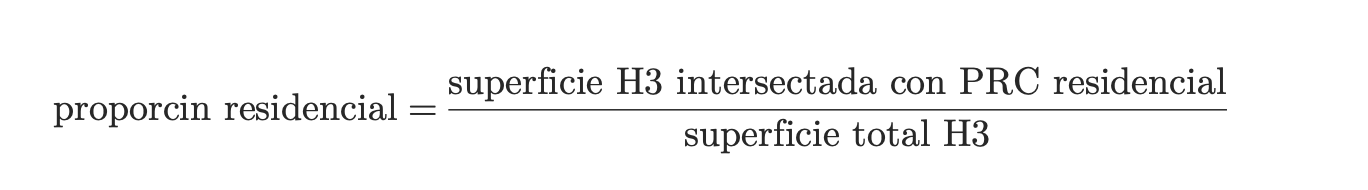

In [14]:
# Intersectar las H3 con las zonas donde el PRC permite uso residencial

interseccion_residencial = gpd.overlay(
    h3_utm[['h3', 'geometry']],
    prc_residencial[['geometry']],
    how='intersection'
)

# Calcular superficie residencial de cada intersección
interseccion_residencial['area_res_m2'] = (
    interseccion_residencial.geometry.area
)

# Sumar las superficies residenciales correspondientes a cada H3
area_res_h3 = (
    interseccion_residencial
    .groupby('h3', as_index=False)['area_res_m2']
    .sum()
)

# Incorporar superficie residencial a la base
h3_factibilidad = h3_factibilidad.merge(
    area_res_h3,
    on='h3',
    how='left'
)

# H3 sin intersección con zonas residenciales
h3_factibilidad['area_res_m2'] = (
    h3_factibilidad['area_res_m2']
    .fillna(0)
)

# Proporción residencial respecto de la superficie total de la H3
h3_factibilidad['prop_residencial'] = (
    h3_factibilidad['area_res_m2'] /
    h3_factibilidad['area_h3_m2']
)

#### 3.3.5. Revisión de la proporción residencial

In [15]:
# Revisar distribución de la proporción residencial

display(
    h3_factibilidad['prop_residencial'].describe()
)

print(
    "H3 sin superficie residencial:",
    (h3_factibilidad['prop_residencial'] == 0).sum()
)

print(
    "H3 con alguna superficie residencial:",
    (h3_factibilidad['prop_residencial'] > 0).sum()
)

count    880.000000
mean       0.617104
std        0.386564
min        0.000000
25%        0.210813
50%        0.807154
75%        0.946237
max        1.000000
Name: prop_residencial, dtype: float64

H3 sin superficie residencial: 167
H3 con alguna superficie residencial: 713


### 3.4. Definición de las alternativas residenciales

A partir de la proporción de superficie residencial calculada para cada celda H3, se construye una variable binaria que identifica las celdas con predominancia de uso residencial permitido por el PRC.

Siguiendo la lógica de asignación proporcional utilizada en el Laboratorio 2, una celda se considera una alternativa residencial cuando al menos el 50% de su superficie corresponde a zonas donde el PRC permite uso residencial.

Este criterio representa predominancia espacial y no implica que las celdas bajo el umbral no puedan contener viviendas o sectores donde el uso residencial esté permitido.

#### 3.4.1. Clasificación de las H3

In [16]:
# Clasificar las H3 según predominancia de superficie residencial

h3_factibilidad['residencial_predominante'] = (
    h3_factibilidad['prop_residencial'] >= 0.50
).astype(int)

print(
    "H3 residenciales:",
    h3_factibilidad['residencial_predominante'].sum()
)

print(
    "H3 no residenciales:",
    (h3_factibilidad['residencial_predominante'] == 0).sum()
)

H3 residenciales: 591
H3 no residenciales: 289


#### 3.4.2. Análisis de sensibilidad del umbral
Como comprobación de robustez, se evalúa cómo cambia el número de celdas clasificadas como residenciales al utilizar distintos umbrales de predominancia.

In [17]:
# Evaluar distintos umbrales de superficie residencial

umbrales = [0.10, 0.25, 0.40, 0.50, 0.60]

resultados_umbral = []

for umbral in umbrales:

    n_h3 = (
        h3_factibilidad['prop_residencial'] >= umbral
    ).sum()

    resultados_umbral.append({
        'umbral_residencial': umbral,
        'h3_residenciales': n_h3,
        'porcentaje_h3': round(
            n_h3 / len(h3_factibilidad) * 100,
            1
        )
    })

sensibilidad_umbral = pd.DataFrame(resultados_umbral)

display(sensibilidad_umbral)

,umbral_residencial,h3_residenciales,porcentaje_h3
0,0.10,682,77.5
1,0.25,649,73.8
2,0.40,614,69.8
3,0.50,591,67.2
4,0.60,561,63.7


#### 3.4.3. Crear el conjunto de alternativas residenciales

In [18]:
# Seleccionar las H3 clasificadas como residenciales

h3_residenciales = h3_factibilidad[
    h3_factibilidad['residencial_predominante'] == 1
].copy()

print("Alternativas residenciales:", len(h3_residenciales))

Alternativas residenciales: 591


### 3.5. Validación del conjunto de alternativas

El conjunto de alternativas definido a partir del PRC se contrasta con las celdas H3 en las que se observan localizaciones residenciales durante el período de análisis. Esta comparación permite evaluar en qué medida la clasificación espacial representa las localizaciones efectivamente observadas y detectar posibles limitaciones asociadas al ámbito cubierto por los instrumentos de planificación.

In [19]:
# H3 con localizaciones residenciales observadas

h3_observadas = set(
    agentes_estimacion['h3']
    .dropna()
    .unique()
)

# H3 clasificadas como alternativas residenciales

h3_alternativas = set(
    h3_residenciales['h3']
)

# Comparar ambos conjuntos

h3_observadas_residenciales = (
    h3_observadas & h3_alternativas
)

h3_observadas_no_residenciales = (
    h3_observadas - h3_alternativas
)

print("H3 observadas:", len(h3_observadas))
print("Alternativas residenciales:", len(h3_alternativas))

print(
    "\nH3 observadas y residenciales:",
    len(h3_observadas_residenciales)
)

print(
    "H3 observadas no clasificadas como residenciales:",
    len(h3_observadas_no_residenciales)
)

print(
    "\nCobertura:",
    round(
        len(h3_observadas_residenciales) /
        len(h3_observadas) * 100,
        2
    ),
    "%"
)

H3 observadas: 518
Alternativas residenciales: 591

H3 observadas y residenciales: 420
H3 observadas no clasificadas como residenciales: 98

Cobertura: 81.08 %


#### 3.5.2 Caracterización de las H3 observadas no clasificadas como residenciales

Se examina la proporción de superficie residencial de las celdas con localizaciones observadas que no cumplen el criterio de predominancia del 50%. Esto permite distinguir entre celdas cercanas al umbral y celdas sin cobertura residencial según los PRC considerados.

In [20]:
# Seleccionar H3 observadas que no cumplen el criterio residencial

revision_no_residenciales = (
    h3_factibilidad[
        h3_factibilidad['h3'].isin(
            h3_observadas_no_residenciales
        )
    ][
        ['h3', 'prop_urbana', 'prop_residencial']
    ]
    .copy()
)

# Clasificar según proporción residencial

revision_no_residenciales['situacion'] = np.select(
    [
        revision_no_residenciales['prop_residencial'] == 0,

        (revision_no_residenciales['prop_residencial'] > 0) &
        (revision_no_residenciales['prop_residencial'] < 0.25),

        (revision_no_residenciales['prop_residencial'] >= 0.25) &
        (revision_no_residenciales['prop_residencial'] < 0.40),

        (revision_no_residenciales['prop_residencial'] >= 0.40) &
        (revision_no_residenciales['prop_residencial'] < 0.50)
    ],
    [
        'Sin superficie residencial PRC',
        'Residencial <25%',
        'Residencial 25-40%',
        'Residencial 40-50%'
    ],
    default='Otra'
)

print(
    revision_no_residenciales['situacion']
    .value_counts()
)

situacion
Sin superficie residencial PRC    54
Residencial 25-40%                19
Residencial <25%                  15
Residencial 40-50%                10
Name: count, dtype: int64


#### 3.5.3 Localizaciones observadas fuera del límite urbano

Se revisa la relación entre las celdas sin superficie residencial según el PRC y el límite urbano, con el objetivo de identificar localizaciones residenciales periféricas que no son capturadas por el ámbito regulado considerado.

In [21]:
# H3 observadas sin superficie residencial según PRC

h3_sin_residencial = revision_no_residenciales[
    revision_no_residenciales['prop_residencial'] == 0
].copy()

# Identificar cuáles están completamente fuera del límite urbano

h3_fuera_limite = set(
    h3_sin_residencial.loc[
        h3_sin_residencial['prop_urbana'] == 0,
        'h3'
    ]
)

print(
    "H3 observadas sin superficie residencial:",
    len(h3_sin_residencial)
)

print(
    "H3 completamente fuera del límite urbano:",
    len(h3_fuera_limite)
)

H3 observadas sin superficie residencial: 54
H3 completamente fuera del límite urbano: 54


#### 3.5.4. Agentes localizados fuera del límite urbano

In [22]:
# Agentes localizados en H3 completamente fuera del límite urbano

agentes_fuera_limite = agentes_estimacion[
    agentes_estimacion['h3'].isin(
        h3_fuera_limite
    )
].copy()

print(
    "Agentes fuera del límite urbano:",
    len(agentes_fuera_limite)
)

print("\nAgentes por comuna:")
print(
    agentes_fuera_limite['comuna']
    .value_counts()
)

print("\nPorcentaje por comuna:")
print(
    agentes_fuera_limite['comuna']
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

Agentes fuera del límite urbano: 324

Agentes por comuna:
comuna
6102    231
6101     93
Name: count, dtype: int64

Porcentaje por comuna:
comuna
6102    71.3
6101    28.7
Name: proportion, dtype: float64


#### 3.5.5. Limitación espacial

El uso de los PRC permite identificar las celdas con predominancia de uso residencial y evaluar su utilización como criterio para definir alternativas territorialmente plausibles. Sin embargo, este criterio no captura completamente las localizaciones residenciales periféricas observadas.

Se identificaron 54 celdas H3 con localizaciones residenciales observadas que se encuentran completamente fuera del límite urbano considerado. Estas celdas contienen 324 agentes, de los cuales 231 (71,3%) corresponden a Machalí y 93 (28,7%) a Rancagua.

Esta limitación es particularmente relevante debido a que el análisis busca estudiar la localización residencial y el proceso de expansión hacia Machalí. Por lo tanto, en caso de restringir el conjunto de elección al ámbito urbano regulado por los instrumentos de planificación considerados, los resultados deberán interpretarse respecto de las decisiones de localización comprendidas dentro de dicho ámbito.

Una extensión futura del análisis podría ampliar el conjunto de elección hacia sectores periurbanos y rurales, incorporando criterios específicos de factibilidad residencial para las áreas ubicadas fuera de los límites urbanos definidos por los PRC.

### 3.6. Visualización del conjunto de alternativas

Se representa espacialmente el conjunto de alternativas residenciales obtenido, junto con las zonas de uso residencial definidas por los PRC y el límite urbano de Rancagua y Machalí. Esta visualización permite comprobar la consistencia espacial de la clasificación de las celdas H3.

#### 3.6.1. Preparación de las capas

In [23]:
# Preparar capas para visualización

crs_mapa = "EPSG:32719"

h3_mapa = h3_factibilidad.to_crs(crs_mapa).copy()
prc_mapa = prc_residencial.to_crs(crs_mapa).copy()
limite_mapa = limite_urbano.to_crs(crs_mapa).copy()

print("H3:", len(h3_mapa))
print("PRC residencial:", len(prc_mapa))
print("Límites urbanos:", len(limite_mapa))

H3: 880
PRC residencial: 164
Límites urbanos: 2


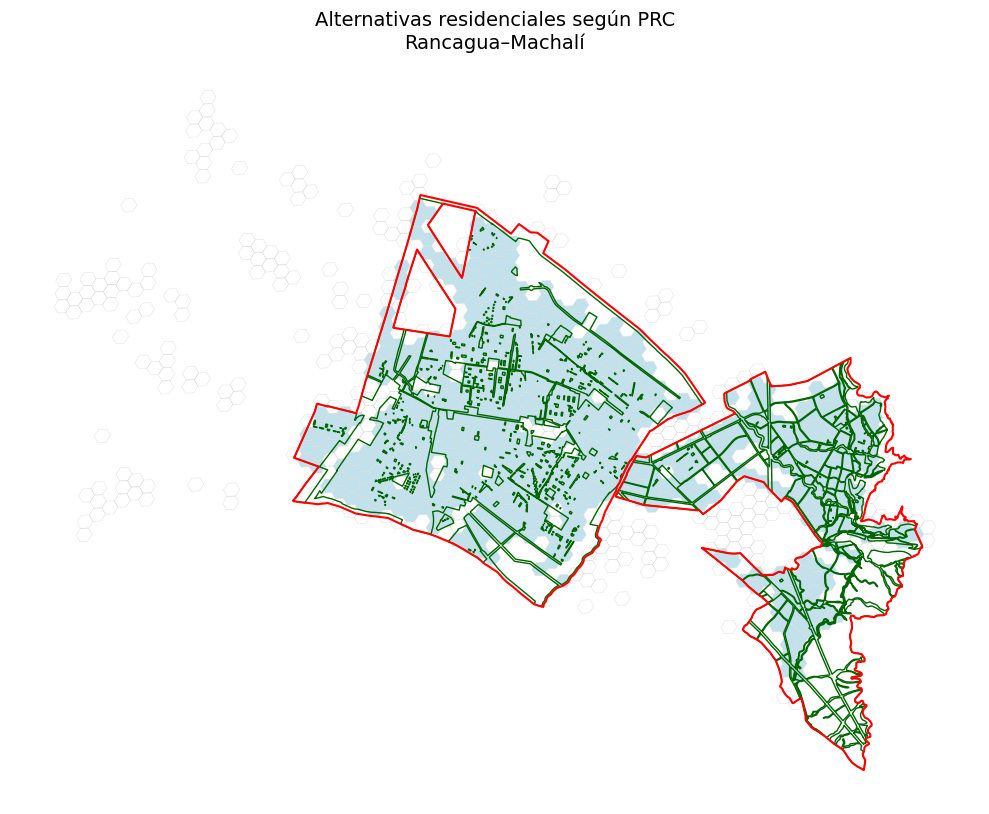

In [24]:
# Unir los polígonos residenciales del PRC para evitar bordes internos
prc_residencial_unido = prc_mapa.dissolve()

# Crear figura
fig, ax = plt.subplots(figsize=(10, 10))

# Todas las H3
h3_mapa.boundary.plot(
    ax=ax,
    color='lightgray',
    linewidth=0.35,
    alpha=0.7
)

# H3 clasificadas como residenciales
h3_mapa[
    h3_mapa['residencial_predominante'] == 1
].plot(
    ax=ax,
    color='lightblue',
    edgecolor='white',
    linewidth=0.25,
    alpha=0.75
)

# Contorno de las zonas residenciales del PRC
prc_residencial_unido.boundary.plot(
    ax=ax,
    color='darkgreen',
    linewidth=1.0
)

# Límite urbano
limite_mapa.boundary.plot(
    ax=ax,
    color='red',
    linewidth=1.5
)

ax.set_title(
    'Alternativas residenciales según PRC\nRancagua–Machalí',
    fontsize=14
)

ax.set_axis_off()

plt.tight_layout()
plt.show()



### 3.6. Definición de la muestra de estimación

#### 3.6.1. Cobertura del conjunto de alternativas residenciales

In [29]:
# Identificar si la alternativa elegida por cada agente
# pertenece al choice set residencial

agentes_estimacion['eleccion_factible'] = (
    agentes_estimacion['h3'].isin(
        h3_residenciales['h3']
    )
)

print("Agentes totales:", len(agentes_estimacion))

print(
    "Agentes con elección dentro del choice set:",
    agentes_estimacion['eleccion_factible'].sum()
)

print(
    "Agentes con elección fuera del choice set:",
    (~agentes_estimacion['eleccion_factible']).sum()
)

print(
    "Cobertura de agentes:",
    round(
        agentes_estimacion['eleccion_factible'].mean() * 100,
        2
    ),
    "%"
)

Agentes totales: 8657
Agentes con elección dentro del choice set: 7801
Agentes con elección fuera del choice set: 856
Cobertura de agentes: 90.11 %


#### 3.6.2. Selección de agentes para la estimación

In [30]:
# Mantener únicamente agentes cuya elección observada
# pertenece al choice set residencial

agentes_choice = (
    agentes_estimacion[
        agentes_estimacion['eleccion_factible']
    ]
    .copy()
    .reset_index(drop=True)
)

# Crear identificador definitivo del agente
agentes_choice['id_agente'] = agentes_choice.index

print("Agentes para estimación:", len(agentes_choice))
print("H3 elegidas:", agentes_choice['h3'].nunique())

print("\nAgentes por año:")
print(
    agentes_choice['año']
    .value_counts()
    .sort_index()
)

print("\nAgentes por comuna:")
print(
    agentes_choice['comuna']
    .value_counts()
)

Agentes para estimación: 7801
H3 elegidas: 420

Agentes por año:
año
2018.0    2284
2019.0    1728
2020.0    1998
2021.0    1403
2022.0     388
Name: count, dtype: int64

Agentes por comuna:
comuna
6101    5620
6102    2181
Name: count, dtype: int64


#### 3.7.1. Correspondencia temporal entre elecciones y atributos

In [31]:
# Para cada agente, utilizar los atributos territoriales
# correspondientes al año anterior a su elección

agentes_choice['año_atributos'] = (
    agentes_choice['año'].astype(int) - 1
)

print(
    agentes_choice[
        ['año', 'año_atributos']
    ]
    .value_counts()
    .sort_index()
)

print(
    "\nAños de atributos requeridos:",
    sorted(agentes_choice['año_atributos'].unique())
)

print(
    "Años disponibles en celdas_estimacion:",
    sorted(celdas_estimacion['año'].unique())
)

año     año_atributos
2018.0  2017             2284
2019.0  2018             1728
2020.0  2019             1998
2021.0  2020             1403
2022.0  2021              388
Name: count, dtype: int64

Años de atributos requeridos: [np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021)]
Años disponibles en celdas_estimacion: [np.int32(2017), np.int32(2018), np.int32(2019), np.int32(2020), np.int32(2021), np.int32(2022)]


#### 3.7.2. Limitación en la distribución temporal de la muestra

La muestra de estimación presenta un número desigual de observaciones entre años. En particular, para 2022 se dispone de 388 agentes, cifra considerablemente menor que la observada en los años anteriores. Esta menor representación puede limitar la capacidad del modelo para capturar patrones específicos de localización correspondientes al último año del período de análisis.

En esta estimación se mantienen las observaciones de 2022 y se conserva su año original, asociándolas a los atributos territoriales de 2021 según el criterio temporal \(t-1\). Como extensión futura, podría evaluarse la agrupación de períodos con baja cantidad de observaciones o la utilización de ventanas temporales más amplias, verificando previamente que dicha agregación sea consistente con la dinámica temporal de las variables explicativas.

#### 3.7.3. Universo de alternativas residenciales

In [33]:
# Choice set espacial definitivo:
# H3 con al menos 50% de superficie residencial según PRC

alternativas = (
    h3_residenciales[
        ['h3', 'prop_urbana', 'prop_residencial']
    ]
    .drop_duplicates(subset='h3')
    .copy()
    .reset_index(drop=True)
)

# Crear identificador de alternativa
alternativas['id_alternativa'] = alternativas.index

print("Alternativas disponibles:", len(alternativas))
print("H3 únicas:", alternativas['h3'].nunique())
print(
    "ID de alternativa únicos:",
    alternativas['id_alternativa'].nunique()
)

# Verificar que todas las elecciones observadas
# pertenezcan al choice set
elecciones_fuera = (
    ~agentes_choice['h3'].isin(alternativas['h3'])
).sum()

print(
    "Elecciones observadas fuera del choice set:",
    elecciones_fuera
)

Alternativas disponibles: 591
H3 únicas: 591
ID de alternativa únicos: 591
Elecciones observadas fuera del choice set: 0


#### 3.7.4. Definición del tamaño del conjunto de elección

In [34]:
# Evaluar distintos tamaños de choice set por agente
# incluyendo siempre la alternativa elegida

tamaños_choice_set = [25, 50, 75, 100, 150, 200, 591]

for n_alt in tamaños_choice_set:
    
    filas = len(agentes_choice) * n_alt
    
    print(
        f"{n_alt:>3} alternativas por agente -> "
        f"{filas:,} filas"
    )

 25 alternativas por agente -> 195,025 filas
 50 alternativas por agente -> 390,050 filas
 75 alternativas por agente -> 585,075 filas
100 alternativas por agente -> 780,100 filas
150 alternativas por agente -> 1,170,150 filas
200 alternativas por agente -> 1,560,200 filas
591 alternativas por agente -> 4,610,391 filas


##### 3.8.2. Revisión de variables candidatas

In [35]:
# Revisar todas las variables disponibles
print("Número total de columnas:", len(celdas_estimacion.columns))

for col in celdas_estimacion.columns:
    print(col)

Número total de columnas: 78
h3
m2_adm._publica_y_defensa
m2_agricola_por_asimilacion
m2_bienes_comunes
m2_bodega_y_almacenaje
m2_comercio
m2_culto
m2_departamento
m2_deporte_y_recreacion
m2_educacion_y_cultura
m2_estacionamiento
m2_habitacional_cat1
m2_habitacional_cat2
m2_habitacional_cat3
m2_habitacional_no_considerado
m2_hotel,_motel
m2_industria
m2_oficina
m2_otros_no_considerados
m2_salud
m2_sitio_eriazo
m2_transporte_y_telec.
n_adm._publica_y_defensa
n_agricola_por_asimilacion
n_bienes_comunes
n_bodega_y_almacenaje
n_comercio
n_culto
n_departamento
n_deporte_y_recreacion
n_educacion_y_cultura
n_estacionamiento
n_habitacional_cat1
n_habitacional_cat2
n_habitacional_cat3
n_habitacional_no_considerado
n_hotel,_motel
n_industria
n_oficina
n_otros_no_considerados
n_salud
n_sitio_eriazo
n_transporte_y_telec.
n_paraderos
m2_residencial
land_use_mix
año
personas
viviendas
hogares
dens_personas_ha
dens_viviendas_ha
personas_por_vivienda
dist_paradero_m
acc_auto_m2_comercio
acc_auto_m2_de

In [36]:
variables_candidatas = [
    'dens_viviendas_ha',
    'land_use_mix',
    'dist_paradero_m',

    'acc_auto_m2_comercio',
    'acc_auto_n_educacion_y_cultura',
    'acc_auto_n_salud',
    'acc_auto_n_paraderos',

    'acc_caminata_m2_comercio',
    'acc_caminata_n_educacion_y_cultura',
    'acc_caminata_n_salud',
    'acc_caminata_n_paraderos'
]

print(
    celdas_estimacion[variables_candidatas]
    .describe()
    .T
    .round(3)
)

                                     count         mean         std  \
dens_viviendas_ha                   5274.0       13.171      14.615   
land_use_mix                        5142.0        0.111       0.153   
dist_paradero_m                     5280.0     1256.554    1551.582   
acc_auto_m2_comercio                5280.0   766255.932  171215.838   
acc_auto_n_educacion_y_cultura      5280.0      807.767     173.374   
acc_auto_n_salud                    5280.0      288.006      63.381   
acc_auto_n_paraderos                5280.0      588.783     131.518   
acc_caminata_m2_comercio            5280.0  1137205.506   61148.766   
acc_caminata_n_educacion_y_cultura  5280.0     1213.537      66.161   
acc_caminata_n_salud                5280.0      418.733      22.187   
acc_caminata_n_paraderos            5280.0      887.156      48.311   

                                           min          25%          50%  \
dens_viviendas_ha                        0.011        1.483        8.42

In [37]:
print(
    celdas_estimacion[variables_candidatas]
    .corr()
    .round(2)
)

                                    dens_viviendas_ha  land_use_mix  \
dens_viviendas_ha                                1.00          0.11   
land_use_mix                                     0.11          1.00   
dist_paradero_m                                 -0.45         -0.33   
acc_auto_m2_comercio                             0.48          0.50   
acc_auto_n_educacion_y_cultura                   0.49          0.48   
acc_auto_n_salud                                 0.46          0.49   
acc_auto_n_paraderos                             0.51          0.47   
acc_caminata_m2_comercio                         0.43          0.36   
acc_caminata_n_educacion_y_cultura               0.43          0.36   
acc_caminata_n_salud                             0.42          0.36   
acc_caminata_n_paraderos                         0.45          0.38   

                                    dist_paradero_m  acc_auto_m2_comercio  \
dens_viviendas_ha                             -0.45                  0

In [38]:
variables_base = [
    'dens_viviendas_ha',
    'land_use_mix',
    'dist_paradero_m',
    'acc_auto_m2_comercio',
    'acc_auto_n_educacion_y_cultura'
]

##### 3.8.4. Distribución de los agentes según tipo de vivienda y comuna

In [39]:
tabla_tipo_comuna = (
    agentes_choice
    .groupby(['comuna', 'destino'])
    .size()
    .unstack(fill_value=0)
)

print("Número de agentes:")
print(tabla_tipo_comuna)

print("\nDistribución porcentual dentro de cada comuna:")
print(
    tabla_tipo_comuna
    .div(tabla_tipo_comuna.sum(axis=1), axis=0)
    .mul(100)
    .round(1)
)

Número de agentes:
destino  habitacional_cat1  habitacional_cat2  habitacional_cat3
comuna                                                          
6101                  3592               1965                 63
6102                  1492                460                229

Distribución porcentual dentro de cada comuna:
destino  habitacional_cat1  habitacional_cat2  habitacional_cat3
comuna                                                          
6101                  63.9               35.0                1.1
6102                  68.4               21.1               10.5


##### 3.8.5. Características de las localizaciones elegidas según tipo de vivienda

In [40]:
# Variables territoriales a comparar
vars_diagnostico = [
    'dens_viviendas_ha',
    'land_use_mix',
    'dist_paradero_m',
    'acc_auto_m2_comercio',
    'acc_auto_n_educacion_y_cultura'
]

# Atributos territoriales necesarios
atributos_eleccion = celdas_estimacion[
    ['h3', 'año'] + vars_diagnostico
].copy()

# Renombrar año para hacer explícita la correspondencia t-1
atributos_eleccion = atributos_eleccion.rename(
    columns={'año': 'año_atributos'}
)

# Asociar cada agente con las características de
# la H3 elegida en el año anterior
agentes_diagnostico = agentes_choice.merge(
    atributos_eleccion,
    on=['h3', 'año_atributos'],
    how='left'
)

# Promedio según tipo de vivienda
resumen_tipo = (
    agentes_diagnostico
    .groupby('destino')[vars_diagnostico]
    .mean()
    .round(2)
)

print(resumen_tipo)

                   dens_viviendas_ha  land_use_mix  dist_paradero_m  \
destino                                                               
habitacional_cat1              15.04          0.05           821.91   
habitacional_cat2              16.21          0.08           501.61   
habitacional_cat3               8.95          0.06          1850.49   

                   acc_auto_m2_comercio  acc_auto_n_educacion_y_cultura  
destino                                                                  
habitacional_cat1             772052.58                          807.88  
habitacional_cat2             808002.81                          852.21  
habitacional_cat3             687120.57                          746.89  


#### 3.8.6. Revisión ampliada de variables candidatas

In [41]:
variables_ampliadas = [
    # Entorno residencial
    'm2_residencial',
    'm2_departamento',
    'dens_personas_ha',
    'dens_viviendas_ha',
    'land_use_mix',

    # Usos de suelo
    'm2_comercio',
    'm2_educacion_y_cultura',
    'm2_oficina',
    'm2_industria',
    'm2_salud',

    # Transporte
    'n_paraderos',
    'dist_paradero_m',

    # Accesibilidad en auto
    'acc_auto_m2_comercio',
    'acc_auto_n_educacion_y_cultura',
    'acc_auto_m2_oficina',
    'acc_auto_n_salud',
    'acc_auto_n_paraderos',

    # Accesibilidad caminando
    'acc_caminata_m2_comercio',
    'acc_caminata_n_educacion_y_cultura',
    'acc_caminata_m2_oficina',
    'acc_caminata_n_salud',
    'acc_caminata_n_paraderos'
]

atributos_ampliados = celdas_estimacion[
    ['h3', 'año'] + variables_ampliadas
].rename(columns={'año': 'año_atributos'})

agentes_ampliado = agentes_choice.merge(
    atributos_ampliados,
    on=['h3', 'año_atributos'],
    how='left'
)

resumen_ampliado = (
    agentes_ampliado
    .groupby('destino')[variables_ampliadas]
    .mean()
    .T
    .round(2)
)

print(resumen_ampliado)

destino                             habitacional_cat1  habitacional_cat2  \
m2_residencial                                9172.75            8975.79   
m2_departamento                                360.19            1283.60   
dens_personas_ha                                40.57              45.09   
dens_viviendas_ha                               15.04              16.21   
land_use_mix                                     0.05               0.08   
m2_comercio                                    194.06             200.89   
m2_educacion_y_cultura                         223.96             238.79   
m2_oficina                                      32.23              55.89   
m2_industria                                   123.42              27.68   
m2_salud                                         7.27               5.78   
n_paraderos                                      0.85               1.18   
dist_paradero_m                                821.91             501.61   
acc_auto_m2_

##### 3.8.7. Redundancia entre variables candidatas

In [42]:


corr = (
    celdas_estimacion[variables_ampliadas]
    .corr()
)

pares = []

for i in range(len(corr.columns)):
    for j in range(i + 1, len(corr.columns)):
        
        r = corr.iloc[i, j]
        
        if abs(r) >= 0.80:
            pares.append([
                corr.columns[i],
                corr.columns[j],
                r
            ])

pares_corr = (
    pd.DataFrame(
        pares,
        columns=['variable_1', 'variable_2', 'correlacion']
    )
    .sort_values(
        'correlacion',
        key=abs,
        ascending=False
    )
)

print(pares_corr.to_string(index=False))

                        variable_1                         variable_2  correlacion
              acc_auto_m2_comercio                   acc_auto_n_salud     0.993390
          acc_caminata_m2_comercio               acc_caminata_n_salud     0.993197
acc_caminata_n_educacion_y_cultura               acc_caminata_n_salud     0.992068
              acc_auto_m2_comercio               acc_auto_n_paraderos     0.988753
    acc_auto_n_educacion_y_cultura                   acc_auto_n_salud     0.988618
          acc_caminata_m2_comercio acc_caminata_n_educacion_y_cultura     0.986110
              acc_auto_m2_comercio     acc_auto_n_educacion_y_cultura     0.985169
              acc_auto_m2_comercio                acc_auto_m2_oficina     0.983163
    acc_auto_n_educacion_y_cultura               acc_auto_n_paraderos     0.982104
                  acc_auto_n_salud               acc_auto_n_paraderos     0.976242
               acc_auto_m2_oficina                   acc_auto_n_salud     0.970392
    

In [43]:


# Variables que queremos evaluar
variables_seleccion = [
    'm2_residencial',
    'm2_departamento',
    'dens_personas_ha',
    'dens_viviendas_ha',
    'land_use_mix',
    'm2_comercio',
    'm2_educacion_y_cultura',
    'm2_oficina',
    'm2_industria',
    'm2_salud',
    'n_paraderos',
    'dist_paradero_m',
    'acc_auto_m2_comercio',
    'acc_auto_n_educacion_y_cultura',
    'acc_auto_m2_oficina',
    'acc_auto_n_salud',
    'acc_auto_n_paraderos'
]

umbral = 0.80

corr = celdas_estimacion[variables_seleccion].corr().abs()

# Triángulo superior de la matriz
upper = corr.where(
    np.triu(np.ones(corr.shape), k=1).astype(bool)
)

# Mostrar variables que entrarían en conflicto
conflictos = []

for col in upper.columns:
    for fila in upper.index:
        r = upper.loc[fila, col]

        if pd.notna(r) and r >= umbral:
            conflictos.append({
                'variable_1': fila,
                'variable_2': col,
                'correlacion': r
            })

conflictos = (
    pd.DataFrame(conflictos)
    .sort_values('correlacion', ascending=False)
)

print("Pares con alta correlación:")
print(conflictos.to_string(index=False))

Pares con alta correlación:
                    variable_1                     variable_2  correlacion
          acc_auto_m2_comercio               acc_auto_n_salud     0.993390
          acc_auto_m2_comercio           acc_auto_n_paraderos     0.988753
acc_auto_n_educacion_y_cultura               acc_auto_n_salud     0.988618
          acc_auto_m2_comercio acc_auto_n_educacion_y_cultura     0.985169
          acc_auto_m2_comercio            acc_auto_m2_oficina     0.983163
acc_auto_n_educacion_y_cultura           acc_auto_n_paraderos     0.982104
              acc_auto_n_salud           acc_auto_n_paraderos     0.976242
           acc_auto_m2_oficina               acc_auto_n_salud     0.970392
              dens_personas_ha              dens_viviendas_ha     0.969608
           acc_auto_m2_oficina           acc_auto_n_paraderos     0.958535
acc_auto_n_educacion_y_cultura            acc_auto_m2_oficina     0.954750
               dist_paradero_m           acc_auto_n_paraderos     0.8702

##### 3.8.9. Variables retenidas para la especificación de modelos

In [45]:
variables_retenidas = [
    # Estructura urbana
    'dens_viviendas_ha',
    'land_use_mix',

    # Usos locales
    'm2_comercio',
    'm2_educacion_y_cultura',
    'm2_oficina',
    'm2_industria',
    'm2_salud',

    # Transporte público
    'dist_paradero_m',

    # Accesibilidad en auto
    'acc_auto_m2_comercio',
    'acc_auto_n_educacion_y_cultura',
    'acc_auto_m2_oficina',
    'acc_auto_n_salud'
]

print("Variables retenidas:", len(variables_retenidas))

for v in variables_retenidas:
    print("-", v)

Variables retenidas: 12
- dens_viviendas_ha
- land_use_mix
- m2_comercio
- m2_educacion_y_cultura
- m2_oficina
- m2_industria
- m2_salud
- dist_paradero_m
- acc_auto_m2_comercio
- acc_auto_n_educacion_y_cultura
- acc_auto_m2_oficina
- acc_auto_n_salud


### 3.9. Preparación de la base para estimación

#### 3.9.1. Revisión de valores faltantes en las alternativas

In [46]:
años_modelo = [2017, 2018, 2019, 2020, 2021]

celdas_modelo = celdas_estimacion[
    (celdas_estimacion['h3'].isin(alternativas['h3'])) &
    (celdas_estimacion['año'].isin(años_modelo))
].copy()

print("Filas esperadas:", 591 * 5)
print("Filas obtenidas:", len(celdas_modelo))
print("H3 únicas:", celdas_modelo['h3'].nunique())
print("Años:", sorted(celdas_modelo['año'].unique()))

faltantes = (
    celdas_modelo[variables_retenidas]
    .isna()
    .sum()
    .sort_values(ascending=False)
)

print("\nValores faltantes por variable:")
print(faltantes)

mask_na = celdas_modelo[variables_retenidas].isna().any(axis=1)

print("\nFilas H3-año con algún NA:", mask_na.sum())
print(
    "H3 distintas afectadas:",
    celdas_modelo.loc[mask_na, 'h3'].nunique()
)

Filas esperadas: 2955
Filas obtenidas: 2955
H3 únicas: 591
Años: [np.int32(2017), np.int32(2018), np.int32(2019), np.int32(2020), np.int32(2021)]

Valores faltantes por variable:
land_use_mix                      43
dens_viviendas_ha                  0
m2_comercio                        0
m2_educacion_y_cultura             0
m2_oficina                         0
m2_industria                       0
m2_salud                           0
dist_paradero_m                    0
acc_auto_m2_comercio               0
acc_auto_n_educacion_y_cultura     0
acc_auto_m2_oficina                0
acc_auto_n_salud                   0
dtype: int64

Filas H3-año con algún NA: 43
H3 distintas afectadas: 16


sacar land use mix

In [47]:
variables_retenidas.remove('land_use_mix')

print("Variables retenidas:", len(variables_retenidas))
for v in variables_retenidas:
    print("-", v)

Variables retenidas: 11
- dens_viviendas_ha
- m2_comercio
- m2_educacion_y_cultura
- m2_oficina
- m2_industria
- m2_salud
- dist_paradero_m
- acc_auto_m2_comercio
- acc_auto_n_educacion_y_cultura
- acc_auto_m2_oficina
- acc_auto_n_salud


In [48]:
años_modelo = [2017, 2018, 2019, 2020, 2021]

celdas_modelo = celdas_estimacion[
    (celdas_estimacion['h3'].isin(alternativas['h3'])) &
    (celdas_estimacion['año'].isin(años_modelo))
].copy()

print("Filas esperadas:", 591 * 5)
print("Filas obtenidas:", len(celdas_modelo))
print("H3 únicas:", celdas_modelo['h3'].nunique())
print("Años:", sorted(celdas_modelo['año'].unique()))

faltantes = (
    celdas_modelo[variables_retenidas]
    .isna()
    .sum()
    .sort_values(ascending=False)
)

print("\nValores faltantes por variable:")
print(faltantes)

mask_na = celdas_modelo[variables_retenidas].isna().any(axis=1)

print("\nFilas H3-año con algún NA:", mask_na.sum())
print(
    "H3 distintas afectadas:",
    celdas_modelo.loc[mask_na, 'h3'].nunique()
)

Filas esperadas: 2955
Filas obtenidas: 2955
H3 únicas: 591
Años: [np.int32(2017), np.int32(2018), np.int32(2019), np.int32(2020), np.int32(2021)]

Valores faltantes por variable:
dens_viviendas_ha                 0
m2_comercio                       0
m2_educacion_y_cultura            0
m2_oficina                        0
m2_industria                      0
m2_salud                          0
dist_paradero_m                   0
acc_auto_m2_comercio              0
acc_auto_n_educacion_y_cultura    0
acc_auto_m2_oficina               0
acc_auto_n_salud                  0
dtype: int64

Filas H3-año con algún NA: 0
H3 distintas afectadas: 0


#### 3.9.2. Escalamiento de variables para la estimación

In [49]:
# Copia para preparar las variables del modelo
celdas_modelo = celdas_modelo.copy()

# Distancia: metros -> kilómetros
celdas_modelo['dist_paradero_km'] = (
    celdas_modelo['dist_paradero_m'] / 1000
)

# Superficies locales: m² -> miles de m²
celdas_modelo['comercio_1000m2'] = (
    celdas_modelo['m2_comercio'] / 1000
)

celdas_modelo['educacion_1000m2'] = (
    celdas_modelo['m2_educacion_y_cultura'] / 1000
)

celdas_modelo['oficina_1000m2'] = (
    celdas_modelo['m2_oficina'] / 1000
)

celdas_modelo['industria_1000m2'] = (
    celdas_modelo['m2_industria'] / 1000
)

celdas_modelo['salud_1000m2'] = (
    celdas_modelo['m2_salud'] / 1000
)

# Accesibilidad a comercio y oficinas: escala 100.000
celdas_modelo['acc_auto_comercio_100k'] = (
    celdas_modelo['acc_auto_m2_comercio'] / 100000
)

celdas_modelo['acc_auto_oficina_100k'] = (
    celdas_modelo['acc_auto_m2_oficina'] / 100000
)

# Accesibilidades basadas en conteos: escala 100
celdas_modelo['acc_auto_educacion_100'] = (
    celdas_modelo['acc_auto_n_educacion_y_cultura'] / 100
)

celdas_modelo['acc_auto_salud_100'] = (
    celdas_modelo['acc_auto_n_salud'] / 100
)

#### 3.9.3. Variables disponibles para la estimación

In [50]:
variables_modelo = [
    # Estructura urbana
    'dens_viviendas_ha',

    # Usos locales
    'comercio_1000m2',
    'educacion_1000m2',
    'oficina_1000m2',
    'industria_1000m2',
    'salud_1000m2',

    # Transporte público
    'dist_paradero_km',

    # Accesibilidad en auto
    'acc_auto_comercio_100k',
    'acc_auto_educacion_100',
    'acc_auto_oficina_100k',
    'acc_auto_salud_100'
]

print("Variables disponibles para estimación:", len(variables_modelo))

for v in variables_modelo:
    print("-", v)

Variables disponibles para estimación: 11
- dens_viviendas_ha
- comercio_1000m2
- educacion_1000m2
- oficina_1000m2
- industria_1000m2
- salud_1000m2
- dist_paradero_km
- acc_auto_comercio_100k
- acc_auto_educacion_100
- acc_auto_oficina_100k
- acc_auto_salud_100


### 3.10. Construcción de la base larga para el modelo de elección

#### 3.10.1. Combinación de agentes y alternativas

In [51]:
# Información mínima de cada agente
agentes_long = agentes_choice[
    ['id_agente', 'h3', 'año', 'año_atributos', 'destino', 'comuna']
].copy()

# Renombrar H3 elegida para distinguirla de la alternativa
agentes_long = agentes_long.rename(
    columns={'h3': 'h3_elegida'}
)

# Alternativas disponibles
alternativas_long = alternativas[
    ['h3', 'id_alternativa']
].copy()

alternativas_long = alternativas_long.rename(
    columns={'h3': 'h3_alternativa'}
)

# Producto cartesiano: cada agente enfrenta las 591 alternativas
base_long = agentes_long.merge(
    alternativas_long,
    how='cross'
)

# Indicador de alternativa elegida
base_long['choice'] = (
    base_long['h3_elegida'] == base_long['h3_alternativa']
).astype(int)

print("Filas esperadas:", len(agentes_choice) * len(alternativas))
print("Filas obtenidas:", len(base_long))

print("Agentes:", base_long['id_agente'].nunique())
print("Alternativas:", base_long['id_alternativa'].nunique())

print(
    "Número de elecciones:",
    base_long['choice'].sum()
)

print(
    "Agentes con exactamente una alternativa elegida:",
    base_long.groupby('id_agente')['choice'].sum().eq(1).sum()
)

Filas esperadas: 4610391
Filas obtenidas: 4610391
Agentes: 7801
Alternativas: 591
Número de elecciones: 7801
Agentes con exactamente una alternativa elegida: 7801


#### 3.10.2. Incorporación de atributos territoriales de las alternativas

In [52]:
# Atributos territoriales por H3 y año
atributos_long = celdas_modelo[
    ['h3', 'año'] + variables_modelo
].copy()

# Renombrar claves para hacer explícita la correspondencia
atributos_long = atributos_long.rename(
    columns={
        'h3': 'h3_alternativa',
        'año': 'año_atributos'
    }
)

# Incorporar atributos de cada alternativa en el año t-1
base_long = base_long.merge(
    atributos_long,
    on=['h3_alternativa', 'año_atributos'],
    how='left',
    validate='many_to_one'
)

print("Filas:", len(base_long))
print("Agentes:", base_long['id_agente'].nunique())
print("Alternativas:", base_long['id_alternativa'].nunique())

# Comprobar faltantes
print("\nValores faltantes:")
print(
    base_long[variables_modelo]
    .isna()
    .sum()
)

# Comprobar nuevamente las elecciones
print(
    "\nAgentes con exactamente una elección:",
    base_long.groupby('id_agente')['choice'].sum().eq(1).sum()
)

Filas: 4610391
Agentes: 7801
Alternativas: 591

Valores faltantes:
dens_viviendas_ha         0
comercio_1000m2           0
educacion_1000m2          0
oficina_1000m2            0
industria_1000m2          0
salud_1000m2              0
dist_paradero_km          0
acc_auto_comercio_100k    0
acc_auto_educacion_100    0
acc_auto_oficina_100k     0
acc_auto_salud_100        0
dtype: int64

Agentes con exactamente una elección: 7801


#### 3.10.3. Validación final de la base de estimación

In [54]:
# Número de alternativas por agente
n_alt_agente = base_long.groupby('id_agente').size()

print("Alternativas por agente:")
print(n_alt_agente.describe())

# Correspondencia temporal
check_temporal = (
    base_long[['año', 'año_atributos']]
    .drop_duplicates()
    .sort_values('año')
    .reset_index(drop=True)
)

print(check_temporal)

print("\nCorrespondencia temporal:")
print(check_temporal)

# Distribución de elecciones por tipo de vivienda
print("\nElecciones por tipo de vivienda:")
print(
    base_long.loc[base_long['choice'] == 1, 'destino']
    .value_counts()
)

# Distribución de elecciones por comuna del agente
print("\nElecciones por comuna:")
print(
    base_long.loc[base_long['choice'] == 1, 'comuna']
    .value_counts()
)

Alternativas por agente:
count    7801.0
mean      591.0
std         0.0
min       591.0
25%       591.0
50%       591.0
75%       591.0
max       591.0
dtype: float64
      año  año_atributos
0  2018.0           2017
1  2019.0           2018
2  2020.0           2019
3  2021.0           2020
4  2022.0           2021

Correspondencia temporal:
      año  año_atributos
0  2018.0           2017
1  2019.0           2018
2  2020.0           2019
3  2021.0           2020
4  2022.0           2021

Elecciones por tipo de vivienda:
destino
habitacional_cat1    5084
habitacional_cat2    2425
habitacional_cat3     292
Name: count, dtype: int64

Elecciones por comuna:
comuna
6101    5620
6102    2181
Name: count, dtype: int64


---

In [27]:
agentes_estimacion.groupby('comuna').size()

comuna
6101    5978
6102    2679
dtype: int64

In [26]:
agentes_estimacion.groupby(['comuna', 'destino']).size()

comuna  destino          
6101    habitacional_cat1    3803
        habitacional_cat2    2072
        habitacional_cat3     103
6102    habitacional_cat1    1652
        habitacional_cat2     616
        habitacional_cat3     411
dtype: int64

In [28]:
agentes_choice = agentes_estimacion[
    agentes_estimacion['comuna'] == 6102
].copy()

print("Agentes Choice Machalí:", len(agentes_choice))
print(agentes_choice['destino'].value_counts())

Agentes Choice Machalí: 2679
destino
habitacional_cat1    1652
habitacional_cat2     616
habitacional_cat3     411
Name: count, dtype: int64


In [ ]:
h3_machali = agentes_estimacion.loc[
    agentes_estimacion['comuna'] == 6102,
    'h3'
].unique()

print("H3 identificados como Machalí:", len(h3_machali))

print(
    "H3 de Machalí presentes en celdas_estimacion:",
    celdas_estimacion['h3'].isin(h3_machali).sum()
)

H3 identificados como Machalí: 169
H3 de Machalí presentes en celdas_estimacion: 169


In [ ]:
manzanas_censales = gpd.read_file("../lab_02/manzanas_censales.geojson")

print(manzanas_censales["COMUNA"].value_counts())
print(manzanas_censales.crs)

COMUNA
RANCAGUA    2419
MACHALÍ      508
Name: count, dtype: int64
EPSG:4326


In [ ]:
# copiar celdas y proyectar a UTM
celdas_utm = celdas_estimacion.to_crs(epsg=32719)

# obtener centroides
centroides = celdas_utm.copy()
centroides['geometry'] = centroides.geometry.centroid

# volver a EPSG:4326
centroides = centroides.to_crs(epsg=4326)

print(centroides.shape)
print(centroides.crs)

(880, 80)
EPSG:4326


In [ ]:
centroides_comuna = gpd.sjoin(
    centroides[['h3', 'geometry']],
    manzanas_censales[['COMUNA', 'geometry']],
    how='left',
    predicate='within'
)

print("Total:", len(centroides_comuna))
print("\nComuna:")
print(centroides_comuna['COMUNA'].value_counts(dropna=False))

Total: 880

Comuna:
COMUNA
RANCAGUA    383
NaN         279
MACHALÍ     218
Name: count, dtype: int64


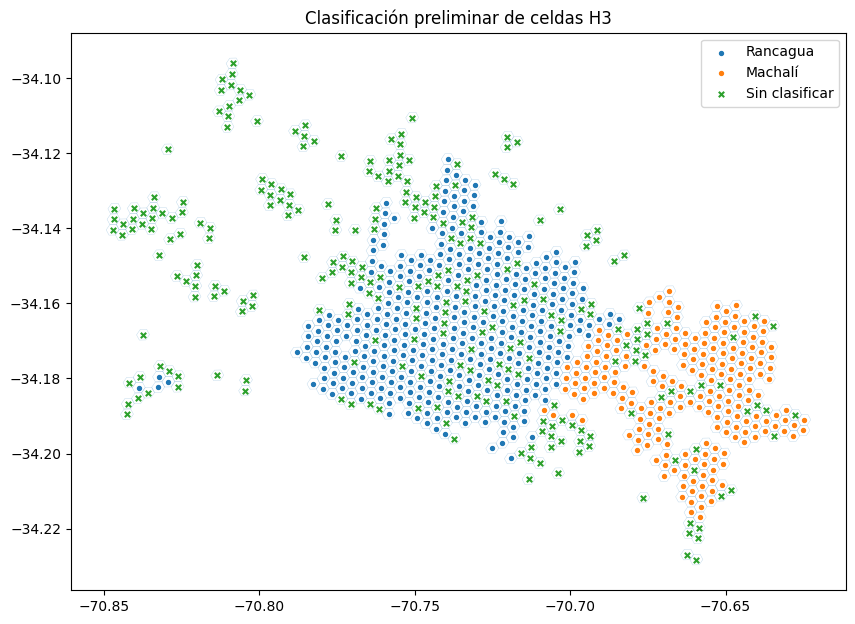

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 10))

# todas las celdas como contexto
celdas_estimacion.boundary.plot(
    ax=ax,
    linewidth=0.3,
    alpha=0.3
)

# centroides Rancagua
centroides_comuna[
    centroides_comuna['COMUNA'] == 'RANCAGUA'
].plot(
    ax=ax,
    markersize=8,
    label='Rancagua'
)

# centroides Machalí
centroides_comuna[
    centroides_comuna['COMUNA'] == 'MACHALÍ'
].plot(
    ax=ax,
    markersize=8,
    label='Machalí'
)

# centroides sin clasificar
centroides_comuna[
    centroides_comuna['COMUNA'].isna()
].plot(
    ax=ax,
    markersize=15,
    marker='x',
    label='Sin clasificar'
)

ax.legend()
ax.set_title('Clasificación preliminar de celdas H3')
plt.show()

In [ ]:
comunas = gpd.read_file("../lab_04/DPA_2023/COMUNAS/COMUNAS_v1.shp")

print(comunas.crs)
print(comunas.columns.tolist())
print(comunas.head())

GEOGCS["GCS_SIRGAS-Chile",DATUM["SIRGAS-Chile",SPHEROID["GRS 1980",6378137,298.257222101,AUTHORITY["EPSG","7019"]],AUTHORITY["EPSG","1254"]],PRIMEM["Greenwich",0],UNIT["Degree",0.0174532925199433],AXIS["Longitude",EAST],AXIS["Latitude",NORTH]]
['CUT_REG', 'CUT_PROV', 'CUT_COM', 'REGION', 'PROVINCIA', 'COMUNA', 'SUPERFICIE', 'geometry']
  CUT_REG CUT_PROV CUT_COM                                     REGION  \
0      11      113   11302  Aysén del General Carlos Ibáñez del Campo   
1      05      055   05503                                 Valparaíso   
2      08      083   08308                                     Biobío   
3      09      092   09209                               La Araucanía   
4      09      092   09202                               La Araucanía   

      PROVINCIA      COMUNA  SUPERFICIE  \
0  Capitán Prat   O'Higgins     7784.69   
1      Quillota    Hijuelas      268.12   
2        Biobío     Quilaco     1123.97   
3       Malleco     Renaico      265.40   
4       

In [ ]:
# Códigos CUT oficiales de la capa DPA:
# 06101 = Rancagua
# 06108 = Machalí
#
# Nota: estos códigos son distintos de la variable 'comuna'
# utilizada en agentes.geojson, donde:
# 6101 = Rancagua
# 6102 = Machalí

comunas_rm = comunas[
    comunas['CUT_COM'].isin(['06101', '06108'])
].copy()

print(comunas_rm[['CUT_COM', 'COMUNA']])
print("Número de comunas:", len(comunas_rm))

    CUT_COM    COMUNA
82    06108   Machalí
324   06101  Rancagua
Número de comunas: 2


In [ ]:
# llevar límites comunales al mismo CRS de los centroides
comunas_rm = comunas_rm.to_crs(centroides.crs)

# asignar comuna según dónde cae el centroide de cada H3
centroides_comuna_oficial = gpd.sjoin(
    centroides[['h3', 'geometry']],
    comunas_rm[['CUT_COM', 'COMUNA', 'geometry']],
    how='left',
    predicate='within'
)

print("Total:", len(centroides_comuna_oficial))

print("\nComuna:")
print(
    centroides_comuna_oficial['COMUNA']
    .value_counts(dropna=False)
)

Total: 880

Comuna:
COMUNA
Rancagua    604
Machalí     276
Name: count, dtype: int64


In [ ]:
# H3 cuyo centroide pertenece oficialmente a Machalí
h3_machali_oficial = centroides_comuna_oficial.loc[
    centroides_comuna_oficial['COMUNA'] == 'Machalí',
    'h3'
]

# Celdas alternativas de Machalí
celdas_machali = celdas_estimacion[
    celdas_estimacion['h3'].isin(h3_machali_oficial)
].copy()

print("Celdas alternativas de Machalí:", len(celdas_machali))

Celdas alternativas de Machalí: 276


In [ ]:
agentes_fuera_choice_set = agentes_choice[
    ~agentes_choice['h3'].isin(celdas_machali['h3'])
]

print("Agentes Choice:", len(agentes_choice))
print("Agentes dentro del choice set:",
      agentes_choice['h3'].isin(celdas_machali['h3']).sum())
print("Agentes fuera del choice set:",
      len(agentes_fuera_choice_set))

Agentes Choice: 2679
Agentes dentro del choice set: 2664
Agentes fuera del choice set: 15


In [ ]:
print(
    agentes_fuera_choice_set[
        ['id_agente', 'comuna', 'h3', 'destino', 'año']
    ].sort_values('h3')
)

        id_agente  comuna               h3            destino     año
180136       8401    6102  89b2c1c0b03ffff  habitacional_cat3  2018.0
180137       8402    6102  89b2c1c0b03ffff  habitacional_cat1  2020.0
180138       8403    6102  89b2c1c0b03ffff  habitacional_cat3  2018.0
180140       8404    6102  89b2c1c0b03ffff  habitacional_cat3  2019.0
180155       8409    6102  89b2c1c0b03ffff  habitacional_cat3  2018.0
180156       8410    6102  89b2c1c0b03ffff  habitacional_cat3  2018.0
180658       8448    6102  89b2c1c0b03ffff  habitacional_cat3  2020.0
180661       8449    6102  89b2c1c0b03ffff  habitacional_cat3  2018.0
180662       8450    6102  89b2c1c0b03ffff  habitacional_cat3  2018.0
180663       8451    6102  89b2c1c0b03ffff  habitacional_cat3  2020.0
180664       8452    6102  89b2c1c0b03ffff  habitacional_cat3  2018.0
180665       8453    6102  89b2c1c0b03ffff  habitacional_cat3  2019.0
180666       8454    6102  89b2c1c0b03ffff  habitacional_cat3  2020.0
159755       6072   

In [ ]:
print(
    "H3 distintos involucrados:",
    agentes_fuera_choice_set['h3'].nunique()
)

print("\nAgentes por H3:")
print(
    agentes_fuera_choice_set
    .groupby('h3')
    .size()
    .sort_values(ascending=False)
)

H3 distintos involucrados: 2

Agentes por H3:
h3
89b2c1c0b03ffff    13
89b2c1ce5c3ffff     2
dtype: int64


In [ ]:
h3_conflicto = [
    '89b2c1c0b03ffff',
    '89b2c1ce5c3ffff'
]

print(
    centroides_comuna_oficial[
        centroides_comuna_oficial['h3'].isin(h3_conflicto)
    ][['h3', 'CUT_COM', 'COMUNA']]
)

                  h3 CUT_COM    COMUNA
497  89b2c1c0b03ffff   06101  Rancagua
855  89b2c1ce5c3ffff   06101  Rancagua


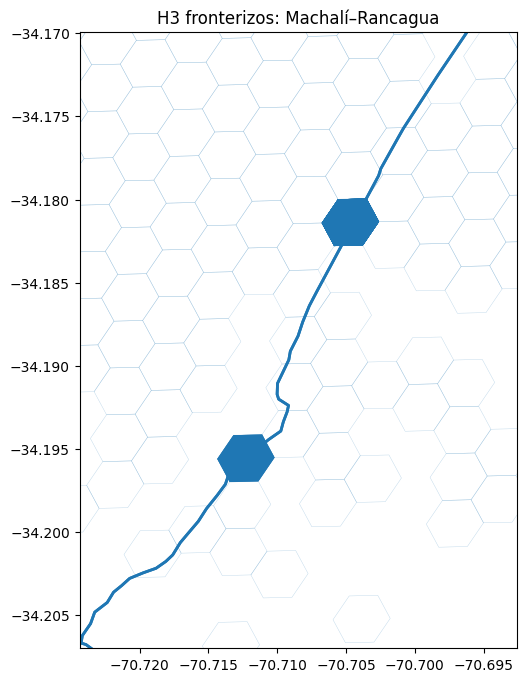

In [ ]:
fig, ax = plt.subplots(figsize=(8, 8))

# límites oficiales
comunas_rm.boundary.plot(
    ax=ax,
    linewidth=2
)

# todos los H3 alrededor como referencia
celdas_estimacion.boundary.plot(
    ax=ax,
    linewidth=0.3,
    alpha=0.3
)

# los dos H3 conflictivos
celdas_estimacion[
    celdas_estimacion['h3'].isin(h3_conflicto)
].plot(
    ax=ax,
    alpha=0.6
)

# ubicaciones de los 15 agentes
agentes_fuera_choice_set.plot(
    ax=ax,
    markersize=25,
    marker='x'
)

# zoom automático alrededor de los dos H3
conflicto = celdas_estimacion[
    celdas_estimacion['h3'].isin(h3_conflicto)
]

xmin, ymin, xmax, ymax = conflicto.total_bounds
margen = 0.01

ax.set_xlim(xmin - margen, xmax + margen)
ax.set_ylim(ymin - margen, ymax + margen)

ax.set_title('H3 fronterizos: Machalí–Rancagua')
plt.show()

El conjunto de alternativas se definió a partir de las celdas H3 cuyos centroides se encuentran dentro del límite administrativo oficial de Machalí. Adicionalmente, se incorporaron dos celdas fronterizas intersectadas por el límite comunal que contienen localizaciones residenciales identificadas como pertenecientes a Machalí en la base de agentes.

In [ ]:
# Incorporar los H3 fronterizos que contienen agentes de Machalí
h3_machali_choice = list(h3_machali_oficial) + h3_conflicto

celdas_machali = celdas_estimacion[
    celdas_estimacion['h3'].isin(h3_machali_choice)
].copy()

print("Celdas del choice set:", len(celdas_machali))

print(
    "Agentes dentro del choice set:",
    agentes_choice['h3'].isin(celdas_machali['h3']).sum()
)

print(
    "Agentes fuera del choice set:",
    (~agentes_choice['h3'].isin(celdas_machali['h3'])).sum()
)

Celdas del choice set: 278
Agentes dentro del choice set: 2679
Agentes fuera del choice set: 0


## 4. Variables explicativas del modelo

### 4.1. Selección de variables

In [ ]:
variables_explicativas_choice = [
    'dens_viviendas_ha',
    'land_use_mix',
    'dist_paradero_m',
    'acc_auto_m2_comercio',
    'acc_auto_n_educacion_y_cultura'
]

### 4.2. Revisión de valores faltantes

In [ ]:
df_celdas = celdas_machali[
    ['h3'] + variables_explicativas_choice
].copy()

print(df_celdas.shape)
print(df_celdas.head())

print("\nValores faltantes:")
print(df_celdas[variables_explicativas_choice].isna().sum())

(278, 6)
                 h3  dens_viviendas_ha  land_use_mix  dist_paradero_m  \
1   89b2c1c42cbffff           1.937039      0.416201      5285.837806   
3   89b2c1c54a3ffff          10.125698      0.646580      2738.028722   
13  89b2c1c5523ffff           0.834232      0.279202      4766.129627   
15  89b2c1c094fffff          14.573591      0.543458       151.791968   
19  89b2c1c502fffff           3.074409      0.363838      4121.270338   

    acc_auto_m2_comercio  acc_auto_n_educacion_y_cultura  
1            3292.533540                        5.130909  
3           23376.814785                       42.328977  
13           7864.230676                       12.768095  
15          51345.176173                       57.570224  
19           5740.590073                        6.198776  

Valores faltantes:
dens_viviendas_ha                 1
land_use_mix                      0
dist_paradero_m                   0
acc_auto_m2_comercio              0
acc_auto_n_educacion_y_cultura    

In [ ]:
# revisamos las celdas que tienen valores faltantes en dens_viviendas_ha
celda_nan = df_celdas[
    df_celdas['dens_viviendas_ha'].isna()
]

print(celda_nan)

                  h3  dens_viviendas_ha  land_use_mix  dist_paradero_m  \
566  89b2c1c098fffff                NaN      0.224244       824.052398   

     acc_auto_m2_comercio  acc_auto_n_educacion_y_cultura  
566          27845.744111                       32.658235  


In [ ]:
print(
    celdas_machali.loc[
        celdas_machali['h3'].isin(celda_nan['h3']),
        ['h3', 'personas', 'viviendas', 'area_ha',
         'dens_personas_ha', 'dens_viviendas_ha']
    ]
)

                  h3  personas  viviendas   area_ha  dens_personas_ha  \
566  89b2c1c098fffff       NaN        NaN  8.960882               NaN   

     dens_viviendas_ha  
566                NaN  


In [ ]:
h3_nan = '89b2c1c098fffff'

print(
    "Agentes que eligieron esta celda:",
    (agentes_choice['h3'] == h3_nan).sum()
)

Agentes que eligieron esta celda: 24


In [ ]:
variables_explicativas_choice = [
    'land_use_mix',
    'dist_paradero_m',
    'acc_auto_m2_comercio',
    'acc_auto_n_educacion_y_cultura'
]

df_celdas = celdas_machali[
    ['h3'] + variables_explicativas_choice
].copy()

print("Alternativas:", len(df_celdas))
print("\nValores faltantes:")
print(df_celdas[variables_explicativas_choice].isna().sum())

Alternativas: 278

Valores faltantes:
land_use_mix                      0
dist_paradero_m                   0
acc_auto_m2_comercio              0
acc_auto_n_educacion_y_cultura    0
dtype: int64


## 5. Construcción de la base Choice

### 5.1. Alternativa elegida por cada agente

In [ ]:
df_elegida = agentes_choice[
    ['id_agente', 'h3']
].copy()

df_elegida['chosen'] = 1

print(df_elegida.shape)
print(df_elegida.head())

print("\nAgentes únicos:", df_elegida['id_agente'].nunique())
print("H3 elegidos distintos:", df_elegida['h3'].nunique())

(2679, 3)
        id_agente               h3  chosen
154887       5978  89b2c1c54abffff       1
155105       5979  89b2c1c5417ffff       1
155107       5980  89b2c1c5417ffff       1
155126       5981  89b2c1c54d3ffff       1
155146       5982  89b2c1c09b7ffff       1

Agentes únicos: 2679
H3 elegidos distintos: 169


In [ ]:
# Todos los agentes
df_agentes = agentes_choice[
    ['id_agente']
].drop_duplicates().copy()

# Producto cartesiano: cada agente x cada alternativa
bd_choice = df_agentes.merge(
    df_celdas,
    how='cross'
)

print("Dimensión:", bd_choice.shape)
print(bd_choice.head())

Dimensión: (744762, 6)
   id_agente               h3  land_use_mix  dist_paradero_m  \
0       5978  89b2c1c42cbffff      0.416201      5285.837806   
1       5978  89b2c1c54a3ffff      0.646580      2738.028722   
2       5978  89b2c1c5523ffff      0.279202      4766.129627   
3       5978  89b2c1c094fffff      0.543458       151.791968   
4       5978  89b2c1c502fffff      0.363838      4121.270338   

   acc_auto_m2_comercio  acc_auto_n_educacion_y_cultura  
0           3292.533540                        5.130909  
1          23376.814785                       42.328977  
2           7864.230676                       12.768095  
3          51345.176173                       57.570224  
4           5740.590073                        6.198776  


### 5.2. Producto cartesiano agente × alternativa

In [ ]:
bd_choice = bd_choice.merge(
    df_elegida[['id_agente', 'h3', 'chosen']],
    on=['id_agente', 'h3'],
    how='left'
)

# Las alternativas que no fueron elegidas reciben chosen = 0
bd_choice['chosen'] = bd_choice['chosen'].fillna(0).astype(int)

### 5.3. Construcción de la variable `chosen`

In [ ]:
print("Filas:", len(bd_choice))
print("Chosen = 1:", bd_choice['chosen'].sum())

chosen_por_agente = bd_choice.groupby('id_agente')['chosen'].sum()

print("Mínimo chosen por agente:", chosen_por_agente.min())
print("Máximo chosen por agente:", chosen_por_agente.max())
print("Agentes con exactamente 1 elección:", (chosen_por_agente == 1).sum())

Filas: 744762
Chosen = 1: 2679
Mínimo chosen por agente: 1
Máximo chosen por agente: 1
Agentes con exactamente 1 elección: 2679


## 6. Estimación del modelo Choice

### 6.1. Preparación de las variables explicativas
Antes de estimar el modelo, se reescalan las variables explicativas para facilitar la interpretación de los coeficientes y mejorar la estabilidad numérica de la estimación.

In [ ]:
# Crear variables reescaladas para la estimación
bd_choice['mix_usos'] = bd_choice['land_use_mix']

# Distancia expresada en kilómetros
bd_choice['dist_paradero_km'] = (
    bd_choice['dist_paradero_m'] / 1000
)

# Accesibilidad a comercio expresada en decenas de miles
bd_choice['acc_comercio_10k'] = (
    bd_choice['acc_auto_m2_comercio'] / 10000
)

# Accesibilidad a educación expresada en decenas
bd_choice['acc_educacion_10'] = (
    bd_choice['acc_auto_n_educacion_y_cultura'] / 10
)

variables_modelo = [
    'mix_usos',
    'dist_paradero_km',
    'acc_comercio_10k',
    'acc_educacion_10'
]

### 6.2. Revisión de las variables del modelo

Se verifica que las variables explicativas presenten variación y no contengan valores faltantes antes de realizar la estimación.

In [ ]:
print(
    bd_choice[variables_modelo]
    .describe()
    .T
)

print("\nValores faltantes:")
print(
    bd_choice[variables_modelo]
    .isna()
    .sum()
)

                     count      mean       std       min       25%       50%  \
mix_usos          744762.0  0.334472  0.114247 -0.000000  0.279202  0.336406   
dist_paradero_km  744762.0  2.464280  1.471918  0.035284  1.237775  2.361379   
acc_comercio_10k  744762.0  1.700036  1.600722  0.068766  0.641944  1.231480   
acc_educacion_10  744762.0  2.223193  1.620498  0.075592  1.010685  1.949161   

                       75%        max  
mix_usos          0.404584   0.646580  
dist_paradero_km  3.661648   5.971583  
acc_comercio_10k  2.182385  10.631135  
acc_educacion_10  3.048240   9.214735  

Valores faltantes:
mix_usos            0
dist_paradero_km    0
acc_comercio_10k    0
acc_educacion_10    0
dtype: int64


### 6.3. Estimación del modelo Multinomial Logit

Se estima un modelo Multinomial Logit (MNL) de elección de localización residencial. Cada agente elige una celda H3 entre las 278 alternativas definidas para Machalí. La utilidad de cada alternativa depende de sus características urbanas y de accesibilidad.

In [ ]:
from xlogit import MultinomialLogit

# Matriz de variables explicativas
X = bd_choice[variables_modelo].values

# Alternativa elegida
y = bd_choice['chosen'].values

# Identificador del agente
ids = bd_choice['id_agente'].values

# Identificador de la alternativa
alts = bd_choice['h3'].values

# Nombres de las variables
varnames = variables_modelo

#### 6.3.1 Modelo 1

In [ ]:
# Inicializar modelo
modelo_choice = MultinomialLogit()

# Estimar modelo
modelo_choice.fit(
    X=X,
    y=y,
    varnames=varnames,
    ids=ids,
    alts=alts
)

# Mostrar resultados
modelo_choice.summary()

Optimization terminated successfully.
    Message: The gradients are close to zero
    Iterations: 8
    Function evaluations: 10
Estimation time= 0.9 seconds
---------------------------------------------------------------------------
Coefficient              Estimate      Std.Err.         z-val         P>|z|
---------------------------------------------------------------------------
mix_usos               -0.9565687     0.2082620    -4.5931019      4.57e-06 ***
dist_paradero_km       -0.5930334     0.0233204   -25.4297740     5.68e-128 ***
acc_comercio_10k       -1.3308925     0.0585573   -22.7280517     1.03e-104 ***
acc_educacion_10        0.9679676     0.0473455    20.4447458       1.9e-86 ***
---------------------------------------------------------------------------
Significance:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Log-Likelihood= -14482.920
AIC= 28973.840
BIC= 28997.412


##### 6.3.1.1 Resultados del Modelo 1

El modelo converge correctamente y las cuatro variables incluidas presentan coeficientes estadísticamente significativos al 1%. Los resultados permiten analizar cómo las características de las celdas se relacionan con la localización observada de nuevos desarrollos residenciales en Machalí durante el período 2018–2022.

##### 6.3.1.2 Diagnóstico del Modelo 1

Se analiza la relación entre las variables explicativas para identificar posibles problemas de correlación y comprender mejor los signos obtenidos en la estimación.

In [ ]:
# Correlación entre variables explicativas

correlaciones = (
    df_celdas[
        [
            'land_use_mix',
            'dist_paradero_m',
            'acc_auto_m2_comercio',
            'acc_auto_n_educacion_y_cultura'
        ]
    ]
    .corr()
)

correlaciones.round(3)

,land_use_mix,dist_paradero_m,acc_auto_m2_comercio,acc_auto_n_educacion_y_cultura
land_use_mix,1.000,0.025,0.017,0.154
dist_paradero_m,0.025,1.000,-0.727,-0.723
acc_auto_m2_comercio,0.017,-0.727,1.000,0.945
acc_auto_n_educacion_y_cultura,0.154,-0.723,0.945,1.000


##### 6.3.1.3 Especificaciones alternativas del modelo

El diagnóstico del Modelo 1 muestra una correlación muy alta entre la accesibilidad a comercio y la accesibilidad a educación (r = 0.945). Además, ambas variables presentan una correlación negativa relativamente alta con la distancia al paradero.

Debido a esta colinealidad, los coeficientes del Modelo 1 deben interpretarse con cautela. Se estiman especificaciones alternativas para evaluar la estabilidad de los signos y evitar incluir simultáneamente variables que representan patrones espaciales muy similares.

#### 6.3.2 Modelo 2

In [ ]:
# MODELO 2: Mix de usos + distancia a paradero + accesibilidad a comercio

variables_m2 = [
    'mix_usos',
    'dist_paradero_km',
    'acc_comercio_10k'
]

modelo_2 = MultinomialLogit()

modelo_2.fit(
    X=bd_choice[variables_m2].values,
    y=bd_choice['chosen'].values,
    varnames=variables_m2,
    ids=bd_choice['id_agente'].values,
    alts=bd_choice['h3'].values
)

modelo_2.summary()

Optimization terminated successfully.
    Message: The gradients are close to zero
    Iterations: 8
    Function evaluations: 9
Estimation time= 0.8 seconds
---------------------------------------------------------------------------
Coefficient              Estimate      Std.Err.         z-val         P>|z|
---------------------------------------------------------------------------
mix_usos                1.2378811     0.1933898     6.4009644      1.82e-10 ***
dist_paradero_km       -0.5400871     0.0208010   -25.9645115     9.12e-133 ***
acc_comercio_10k       -0.3125420     0.0207503   -15.0620811      2.83e-49 ***
---------------------------------------------------------------------------
Significance:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Log-Likelihood= -14697.263
AIC= 29400.526
BIC= 29418.205


#### 6.3.3 Modelo 3

In [ ]:
# MODELO 3: Mix de usos + distancia a paradero + accesibilidad a educación

variables_m3 = [
    'mix_usos',
    'dist_paradero_km',
    'acc_educacion_10'
]

modelo_3 = MultinomialLogit()

modelo_3.fit(
    X=bd_choice[variables_m3].values,
    y=bd_choice['chosen'].values,
    varnames=variables_m3,
    ids=bd_choice['id_agente'].values,
    alts=bd_choice['h3'].values
)

modelo_3.summary()

Optimization terminated successfully.
    Message: The gradients are close to zero
    Iterations: 7
    Function evaluations: 9
Estimation time= 0.8 seconds
---------------------------------------------------------------------------
Coefficient              Estimate      Std.Err.         z-val         P>|z|
---------------------------------------------------------------------------
mix_usos                1.1604006     0.1897628     6.1150061      1.11e-09 ***
dist_paradero_km       -0.3962506     0.0196025   -20.2142609      1.11e-84 ***
acc_educacion_10       -0.1268587     0.0170289    -7.4495926      1.26e-13 ***
---------------------------------------------------------------------------
Significance:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Log-Likelihood= -14808.395
AIC= 29622.790
BIC= 29640.470


## aaa

In [ ]:
# filtrar por variables y multiplicación matricial con .dot()
variables = ['m2_comercio', 'm2_departamento', 'n_deporte_y_recreacion', 'n_educacion_y_cultura', 'm2_habitacional', 'm2_industria', 'm2_oficina', 'n_salud', 'n_paraderos']

accesibilidades_auto = impedance_auto.dot(celdas[variables])
accesibilidades_caminata = impedance_caminata.dot(celdas[variables])

# renombrar columnas
accesibilidades_auto.columns = [f"acc_auto_{col}" for col in accesibilidades_auto.columns]
accesibilidades_caminata.columns = [f"acc_caminata_{col}" for col in accesibilidades_caminata.columns]

# agregar geometría
accesibilidades_auto = celdas[['h3', 'geometry']].merge(accesibilidades_auto, left_index=True, right_index=True, how='left')
accesibilidades_caminata = celdas[['h3', 'geometry']].merge(accesibilidades_caminata, left_index=True, right_index=True, how='left')

In [ ]:
# definir variables explicativas
variables_explicativas_choice = [
    'acc_auto_m2_comercio', 
    'acc_auto_m2_departamento',
    'acc_auto_n_deporte_y_recreacion', 
    'acc_auto_n_educacion_y_cultura',
    'acc_auto_m2_habitacional', 
    'acc_auto_m2_industria',
    'acc_auto_m2_oficina', 
    'acc_auto_n_salud']

# extraer DataFrame con las columnas de celdas que usaremos de explicativas
df_celdas = celdas_estimacion[['h3'] + variables_explicativas_choice].copy()

# crear DataFrame con la celda elegida
df_elegida = agentes_estimacion[['id_agente', 'h3']].assign(chosen=1)
df_elegida = df_elegida.merge(df_celdas, on='h3', how='left')

# crear el conjunto de elección (producto cartesiano entre agentes y celdas)
all_celdas = df_celdas.assign(key=1)
all_agents = agentes_estimacion[['id_agente']].assign(key=1)
bd_choice = all_agents.merge(all_celdas, on='key', how='left').drop('key', axis=1)

# unir con la información real de la celda elegida
bd_choice = bd_choice.merge(df_elegida[['id_agente', 'h3', 'chosen']], on=['id_agente', 'h3'], how='left')
bd_choice['chosen'] = bd_choice['chosen'].fillna(0)

# reemplazar valores nulos en las variables explicativas con 0
bd_choice[variables_explicativas_choice] = bd_choice[variables_explicativas_choice].fillna(0)

# ver DataFrame final
bd_choice.head()

### Estimación del Modelo *Choice*

A continuación, proporcionaremos todos los argumentos requeridos al método .fit y ajustar así correctamente nuestro modelo *choice* en `xlogit`.

In [ ]:
from xlogit import MultinomialLogit
import pickle

# ajustar el modelo con xlogit
choice_model = MultinomialLogit()
choice_model.fit(
    X=bd_choice[variables_explicativas_choice],
    y=bd_choice['chosen'],
    varnames=variables_explicativas_choice,
    ids=bd_choice['id_agente'],
    alts=bd_choice['h3'])

# guardar el modelo en .pickle
with open("choice.pickle", "wb") as file:
    pickle.dump(choice_model, file)

# mostrar resumen del modelo
choice_model.summary()

Cabe señalar que el modelo estimado en este laboratorio es incompleto: falta incorporar un **modelo hedónico de precios a partir de una Regresión Lineal Múltiple** usando `statsmodels` u otras librerías similares.

---

## 5. Modelo Bid (con *`biogeme`*)

El modelo Bid asume que la localización es “ganada” por una categoría / uso de suelo. A modo representativo, en este laboratorio consideraremos que sólo los agentes habitacionales "pujan" por una localización, por lo cual definiremos las categorías $c \in \{1,2,3\}$ en función de la calidad de la construcción. Con ello, definimos la disposición a pagar (*willingness to pay*, WTP) de cada categoría  $c$  por una localización  $i$  de la siguiente manera.

$WTP_{c,i} = \beta_{c,0} + \beta_{c,1} \cdot X_{i,1} + \beta_{c,2} \cdot X_{i,2} + \dots$

En este caso,

- $\beta_{c,k}$  son los coeficientes a estimar para la categoría  $c$  y variable $k$.
- $X_{i,k}$  son las variables explicativas de la localización  $i$.

La probabilidad de que la categoría  $c$  gane la subasta por la localización  $i$  se define a continuación.

$P_{i}(c) = \frac{\exp(WTP_{c,i})}{\sum_{k} \exp(WTP_{k,i})}$

Para evitar colinealidad, fijamos el intercepto de una categoría (por ejemplo,  $c = 1$ ) a cero.

### Preparación de la Base de Datos *Bid*

En el siguiente ejemplo, consideraremos un conjunto de variables explicativas para preparar nuestro modelo Bid para `biogeme`.

In [ ]:
import biogeme.database as db

# seleccionar las columnas relevantes para el modelo bid
variables_explicativas_bid = ['acc_auto_m2_comercio', 'acc_auto_n_educacion_y_cultura', 'acc_auto_m2_habitacional', 'acc_auto_m2_industria', 'acc_auto_n_salud']

# extraer DataFrame con las columnas de celdas que usaremos de explicativas
df_celdas = celdas_estimacion[['h3', 'id_celda'] + variables_explicativas_bid].copy()

# preparar la base de datos para biogeme
bd_bid = agentes_estimacion.merge(df_celdas, on='h3', how='left', suffixes=('_ag','_cell'))

# seleccionar solo las columnas necesarias
bd_bid = bd_bid[['id_agente','cat_vivienda', 'superficie_construida', 'id_celda'] + variables_explicativas_bid]

# ver las primeras filas
bd_bid.head()

In [ ]:
# definir la base de datos para biogeme
database = db.Database('Bid', bd_bid)
globals().update(database.variables)

### Estimación del Modelo *Bid*

A continuación, proporcionaremos todos los argumentos requeridos al método .estimate y ajustar así correctamente nuestro modelo *bid* en `biogeme`. Nuevamente, es importante recordar que el modelo Bid estimado en este laboratorio es representativo, considerando que **se requiere estudiar diferentes especificaciones que combinen accesibilidades en diferentes modos de transporte**, de acuerdo a lo revisado en el Laboratorio 3. 

In [ ]:
from biogeme import models
from biogeme.expressions import Beta
import biogeme.biogeme as bio

# definir las variables y categorías
xh = ['C']
zi = variables_explicativas_bid
total_vars = xh+zi
categorias = 3

# definir los parámetros a estimar
betas = {}
for c in range(1, categorias + 1):
    for v in total_vars:
        if c == 1:
            fixed = 1
        else:
            fixed = 0
        aux_beta = Beta(f'B_{v}_H{c}', 0, -100, 100, fixed)
        betas.update({f'B_{v}_H{c}': aux_beta})

# definir la disposición a pagar de cada categoría
V = {}
av = {}
for c in range(1, categorias + 1):
    DP_aux = 0
    for v in xh:
        DP_aux += betas[f'B_{v}_H{c}']
    for v in zi:
        DP_aux += betas[f'B_{v}_H{c}']*database.variables[v]
    V.update({c: DP_aux})
    av.update({c: 1})

# definir la log-verosimilitud
logprob = models.loglogit(V, av, cat_vivienda)

# (opcional) definir el peso de cada observación
bio.WEIGHT = superficie_construida

# crear el objeto biogeme y estimar el modelo
biogeme = bio.BIOGEME(database, logprob)
biogeme.modelName = 'bid'
bid_model = biogeme.estimate()

# guardar el modelo en .pickle
with open("bid.pickle", "wb") as file:
    pickle.dump(bid_model, file)

Con esto completamos el Laboratorio 4 sobre estimación de modelos de localización basados en un enfoque *bid* y *choice* con las librerías `xlogit` y `Biogeme` de Python.

**Fin del Laboratorio 4**

---

En el próximo laboratorio, exploraremos cómo utilizar nuestros estimadores de los modelos de localización para simular nuevas localizaciones futuras.